In [1]:
from __future__ import annotations

try:
    import anndata
    import scanpy
except ImportError:
    print("Instalando dependências compatíveis com o ambiente do Colab...")
    # Mantém o pandas travado na versão esperada pelo Colab (2.2.3)
    !pip install -q "pandas==2.2.3" anndata scanpy

# Pipeline Genérico Hopfield para scRNA-seq

Executa o fluxo científico fim a fim:
- **1.** Configuração de Ambiente e Repositório
- **2.** Binarização de matrizes scRNA-seq
- **3.** Alinhamento de espaços gênicos com sentinela neutra (0.5)
- **4.** Adição de genes faltantes ao conjunto alvo
- **5.** Projeção dimensional compacta (rSWeeP via R / UFPR)
- **5.1** Projeção SWeeP do Alvo Pré-Hopfield (com Sentinela 0.5)
- **9.** Extração de padrões de subclusters por classe biológica (`perf180`)
- **12.** Auto-imputação — Ref -> Ref
- **12.1** Diagnóstico Formal de Overfitting e Robustez (`AuditorOverfittingHopfield`)
- **12.2** Otimização de Hiperparâmetros via Algoritmo Genético (`OtimizadorGeneticoHopfield`)
- **12.3** Treinamento da Rede Hopfield com Configuração Ótima do AG (`rede{n_padroes}`)
- **13.** Imputação cross-dataset — Mathys com Sentinela Neutra 0.5
- **14.** Seleção de Features Gênicas e Heatmap de Biomarcadores via SHAP (`ADR 023`)

In [2]:

import gc
import importlib
import os
import shutil
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import torch
from numpy.typing import NDArray
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DO REPOSITÓRIO E VALIDAÇÃO FAIL FAST DE INTEGRIDADE GIT (COLAB)
# ==============================================================================
REPO_NAME = "pipiline_hopifield"
REPO_URL = "https://github.com/letdevx/pipiline_hopifield.git"
REPO_BRANCH = "reconstrução_Pan_Mathys"
DEST_PATH = f"/content/{REPO_NAME}"

# Commit hash que o HEAD da VM DEVE conter (aceita hash curto de 7+ chars ou SHA-1 de 40 chars)
# OBRIGATÓRIO NO GOOGLE COLAB: previne execução com código defasado por esquecimento de 'git push'
EXPECTED_COMMIT = "4bada1c"


def _is_google_colab() -> bool:
    """Detecta se a execução atual está ocorrendo no Google Colab."""
    return (
        "google.colab" in sys.modules
        or os.path.exists("/content")
        or os.environ.get("COLAB_GPU") is not None
        or os.environ.get("COLAB_RELEASE_TAG") is not None
    )


def sincronizar_e_validar_repo_colab(
    repo_url: str,
    dest_path: str,
    branch: str,
    expected_commit: str | None,
) -> dict[str, str] | None:
    """Sincroniza o repositório na VM do Colab e valida o commit HEAD (Fail Fast).

    Raises
    ------
    RuntimeError
        Se EXPECTED_COMMIT for omitido no Colab ou divergir do HEAD clonado.
    """
    if not _is_google_colab():
        print(
            "[Git Validador] Execução em ambiente local detectada. "
            "Sincronização remota e validação estrita de commit do Colab ignoradas."
        )
        return None

    # 1. Validação de obrigatoriedade no ambiente Colab
    if expected_commit is None or not expected_commit.strip():
        raise RuntimeError(
            "\n"
            + "=" * 80
            + "\n[FALHA DE INTEGRIDADE - FAIL FAST] COMMIT ESPERADO NÃO INFORMADO\n"
            + "=" * 80
            + "\nNo ambiente do Google Colab, a variável EXPECTED_COMMIT é obrigatória!\n"
            + "Defina o hash do commit desejado antes de executar o notebook para evitar\n"
            + "execuções não reproduzíveis ou versões obsoletas do código.\n"
            + "\nExemplo:\n"
            + "    EXPECTED_COMMIT = '058e839'  # Hash obtido via 'git rev-parse --short HEAD'\n"
            + "=" * 80
        )

    exp_clean = expected_commit.strip().lower()
    if len(exp_clean) < 7:
        raise RuntimeError(
            f"O hash informado '{expected_commit}' possui menos de 7 caracteres. "
            "Forneça pelo menos 7 caracteres para validação inequívoca."
        )

    # 2. Clona se o repositório ainda não existir na VM
    if not os.path.exists(dest_path):
        print(f"[Colab Git] Clonando '{repo_url}' em '{dest_path}'...")
        res_clone = subprocess.run(
            ["git", "clone", repo_url, dest_path],
            capture_output=True,
            text=True,
            check=False,
        )
        if res_clone.returncode != 0:
            raise RuntimeError(
                f"Falha ao clonar repositório:\n{res_clone.stderr.strip()}"
            )

    # 3. Checkout e atualização da branch remota na VM
    print(f"[Colab Git] Atualizando branch '{branch}' a partir de origin...")
    subprocess.run(
        ["git", "-C", dest_path, "checkout", branch],
        capture_output=True,
        text=True,
        check=False,
    )
    subprocess.run(
        ["git", "-C", dest_path, "fetch", "origin", branch],
        capture_output=True,
        text=True,
        check=False,
    )
    res_pull = subprocess.run(
        ["git", "-C", dest_path, "pull", "origin", branch],
        capture_output=True,
        text=True,
        check=False,
    )
    if res_pull.returncode != 0:
        print(f"[Colab Git] Aviso durante git pull:\n{res_pull.stderr.strip()}")

    # 4. Inspeciona o commit HEAD da VM
    def _git_meta(args: list[str]) -> str:
        return subprocess.run(
            ["git", "-C", dest_path, *args],
            capture_output=True,
            text=True,
            check=True,
        ).stdout.strip()

    head_completo = _git_meta(["rev-parse", "HEAD"]).lower()
    head_curto = _git_meta(["rev-parse", "--short", "HEAD"]).lower()
    autor = _git_meta(["log", "-1", "--format=%an"])
    data = _git_meta(["log", "-1", "--format=%ad", "--date=iso"])
    mensagem = _git_meta(["log", "-1", "--format=%s"])

    coincide = head_completo.startswith(exp_clean) or (exp_clean == head_curto)

    if not coincide:
        msg_erro = (
            "\n"
            + "=" * 80
            + "\n[FALHA DE INTEGRIDADE - FAIL FAST] DIVERGÊNCIA DE COMMIT NO GOOGLE COLAB\n"
            + "=" * 80
            + f"\n• Commit Esperado : {expected_commit}"
            + f"\n• Commit no Colab : {head_curto} ({head_completo})"
            + f"\n• Branch atual    : {branch}"
            + f"\n• Autor do Commit : {autor}"
            + f"\n• Data do Commit  : {data}"
            + f"\n• Mensagem        : {mensagem}"
            + "\n"
            + "-" * 80
            + "\nMOTIVO DA INTERRUPÇÃO:"
            + "\nO repositório clonado na VM do Google Colab não está no commit esperado."
            + "\nVocê provavelmente esqueceu de fazer push dos commits locais do seu laptop!"
            + "\n"
            + "\nCOMO CORRIGIR:"
            + "\n1. No terminal do seu laptop, envie os commits mais recentes:"
            + "\n       git status"
            + f"\n       git push origin {branch}"
            + "\n2. No Google Colab, re-execute esta célula para atualizar a VM e prosseguir."
            + "\n"
            + "=" * 80
        )
        raise RuntimeError(msg_erro)

    print(
        f"[Git Validador] Integridade confirmada! HEAD no commit esperado: "
        f"{head_curto} - '{mensagem}' (Branch: {branch})"
    )
    return {
        "hash_completo": head_completo,
        "hash_curto": head_curto,
        "autor": autor,
        "data": data,
        "mensagem": mensagem,
        "branch": branch,
    }


# Executa a verificação na inicialização da célula
sincronizar_e_validar_repo_colab(
    repo_url=REPO_URL,
    dest_path=DEST_PATH,
    branch=REPO_BRANCH,
    expected_commit=EXPECTED_COMMIT,
)

# Adiciona caminhos do repositório ao sys.path se estiver no Colab
if _is_google_colab():
    for _p in (DEST_PATH, os.path.join(DEST_PATH, "src")):
        if _p not in sys.path:
            sys.path.insert(0, _p)

In [4]:
try:
    from google.colab import drive  # type: ignore

    if not os.path.exists("/content/drive"):
        print("[Colab] Montando Google Drive em /content/drive...")
        drive.mount("/content/drive")
except (ImportError, Exception):
    pass

DRIVE_INPUTS = (
    "/content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs"
)
!ls "{DRIVE_INPUTS}"

Mounted at /content/drive
celltypeBinF_eceltypename.csv	  orthbase_mproj_600d.rds
cell_types_binarioF.txt		  pan_anotado.h5ad
featuresF.tsv			  PAN_Bin
featuresM.tsv			  pan_com_sentinela_05.h5ad
featuresPANcorrigido.tsv	  PanNumerico.csv
matrix_Pan.mtx			  requirements.txt
matriz_anotada_finalM.h5ad	  script01_analises_preliminares.ipynb
matrizFiltradaeNormalizadaF.h5ad  tipos_celulares_numericoMs.txt
matriz_Pan05.mtx


In [5]:
import config

importlib.reload(config)

<module 'config' from '/content/pipiline_hopifield/src/config.py'>

In [6]:
try:
    pass
    %load_ext autoreload
    %autoreload 2
except Exception:
    pass

# Detecção robusta do diretório raiz e de src/ para Jupyter, Scripts e Colab
if "__file__" in globals():
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    ROOT_DIR = os.path.abspath(os.getcwd())
    if not os.path.exists(os.path.join(ROOT_DIR, "src")) and os.path.exists(
        os.path.join(os.path.dirname(ROOT_DIR), "src")
    ):
        ROOT_DIR = os.path.dirname(ROOT_DIR)

SRC_DIR = os.path.join(ROOT_DIR, "src")
for p in (ROOT_DIR, SRC_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

import config

importlib.reload(config)
import preprocessing
from config import (
    OUT_ALINHAMENTO,
    OUT_BINARIZACAO,
    OUT_HOPFIELD,
    OUT_IMPUTACAO,
    OUT_MTX_ALVO_IMPUTADO,
    OUT_MTX_ALVO_SENTINELA,
    OUT_MTX_REFERENCIA,
    OUT_SHAP,
    OUT_SWEEP_ALVO_POS_IMPUTACAO,
    OUT_SWEEP_POS_IMPUTACAO,
    OUT_TOP_GENES,
    OUTPUTS,
    PATH_ALVO,
    PATH_FEATURES_ALVO,
    PATH_FEATURES_REFERENCIA,
    PATH_LABELS_ALVO,
    PATH_LABELS_REFERENCIA,
    PATH_ORTHBASE_RDS,
    PATH_REFERENCIA,
    PATH_SWEEP_ALVO,
    PATH_SWEEP_REFERENCIA,
    configurar_diretorios,
)

# Importação defensiva com fallback para compatibilidade com ambientes Colab sem git pull
try:
    from config import PATH_SWEEP_ALVO_SENTINELA
except ImportError:
    PATH_SWEEP_ALVO_SENTINELA = getattr(
        config,
        "PATH_SWEEP_ALVO_SENTINELA",
        os.path.join(
            getattr(
                config,
                "OUT_TREINAMENTO",
                os.path.join(OUTPUTS, "treinamento"),
            ),
            "matriz_reduzida_sweepALVO_sentinela.txt",
        ),
    )

print(f"[Config] Diretório de saídas ativo: {OUTPUTS}")
print(
    f"[Config] Referência: '{getattr(config, 'NOME_REF', 'ref')}' | Alvo: '{getattr(config, 'NOME_ALVO', 'alvo')}'"
)

importlib.reload(preprocessing)
import alinhamento

importlib.reload(alinhamento)
import treinamento

importlib.reload(treinamento)

from alinhamento import (
    AlinhadorEsparso,
    AnalisadorSobreposicao,
    ExportadorMTX,
    LeitorFeatures,
    ValidadorAlinhamento,
    ValidadorFeatures,
    ValidadorOrdemGenes,
)
from preprocessing import Binarizador
from treinamento import (
    AuditorOverfittingHopfield,
    AvaliadorHopfield,
    CarregadorDadosFujita,
    ExportadorImputacao,
    ExtratorPadroesSubcluster,
    HopfieldClassifierWrapper,
    ModernHopfieldNetwork,
    ProjetorSWeePR,
    ProjetorSWeP,
    SelecionadorGenesSHAPHopfield,
)
from treinamento.hopfield_utils import wsort

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    # Garante determinismo em operações CUDA (útil para reprodutibilidade)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Dispositivo: {device} ({torch.cuda.get_device_name(0)})")
    print(
        f"VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )
else:
    device = torch.device("cpu")
    print(f"Dispositivo: {device} (GPU não disponível)")

[Config] Diretório de saídas ativo: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM
[Config] Referência: 'pan_anotado' | Alvo: 'matriz_anotada_finalM'
Dispositivo: cuda (NVIDIA A100-SXM4-80GB)
VRAM disponível: 85.09 GB



#### 2. Binarização
 Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1, zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e pula o processamento nesse caso.

In [7]:
binarizador_ref = Binarizador(path_h5ad=PATH_REFERENCIA, out_dir=OUT_BINARIZACAO)
binarizador_alvo = Binarizador(path_h5ad=PATH_ALVO, out_dir=OUT_BINARIZACAO)

binarizador_ref.binarizar(os.path.split(PATH_REFERENCIA)[-1])
binarizador_alvo.binarizar(os.path.split(PATH_ALVO)[-1])

print("Referência binarizada em:", binarizador_ref.path_binarizada)
print("Alvo binarizado em:", binarizador_alvo.path_binarizada)

[Binarizador] Arquivo já existe, pulando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/binarizacao/pan_anotado/pan_anotado.h5ad
[Binarizador] Arquivo já existe, pulando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/binarizacao/matriz_anotada_finalM/matriz_anotada_finalM.h5ad
Referência binarizada em: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/binarizacao/pan_anotado/pan_anotado.h5ad
Alvo binarizado em: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/binarizacao/matriz_anotada_finalM/matriz_anotada_finalM.h5ad


#### 3. Alinhamento de espaços gênicos ↔️
 Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita, 32 643 no Mathys, ~30 312 em comum).
 O alinhamento:
 1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
 2. Valida a integridade dos arquivos de features e a compatibilidade com as matrizes AnnData.
 3. Define a ordem canônica dos genes baseada no Fujita (referência).
 4. Realinha ambas as matrizes para esse espaço canônico.
    - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
 5. Valida que as duas matrizes resultantes têm genes na mesma ordem.

In [8]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_REFERENCIA, PATH_FEATURES_ALVO)
leitor.ler()
print(leitor)
assert leitor.map_f is not None and leitor.map_m is not None
assert (
    binarizador_ref.path_binarizada is not None
    and binarizador_alvo.path_binarizada is not None
)

[LeitorFeatures] Referência : 61541 genes mapeados
[LeitorFeatures] Alvo       : 32738 genes mapeados
LeitorFeatures(
  path_features_referencia = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs/featuresPANcorrigido.tsv
  path_features_alvo       = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs/featuresM.tsv
  map_referencia           = 61541 genes
  map_alvo                 = 32738 genes
)


In [11]:
# Passo 1.5 — Validação Prévia de Compatibilidade e Ordem de Colunas (Fail-Fast)
validador_feat = ValidadorFeatures(min_match_pct=50.0, min_genes_comuns=1000)
validador_feat.validar_tudo(
    path_features_ref=PATH_FEATURES_REFERENCIA,
    path_features_alvo=PATH_FEATURES_ALVO,
    path_h5ad_ref=binarizador_ref.path_binarizada,
    path_h5ad_alvo=binarizador_alvo.path_binarizada,
    map_f=leitor.map_f,
    map_m=leitor.map_m,
)


🔍 [ValidadorFeatures] Iniciando Auditoria de Features e AnnData
[ValidadorFeatures] Formato do arquivo (Referência (Fujita)): OK (100.0% Ensembl na Col 0)
[ValidadorFeatures] Formato do arquivo (Alvo (Mathys)): OK (99.9% Ensembl na Col 0)
[ValidadorFeatures] Compatibilidade AnnData x Features (Referência (Fujita)): OK (100.0% de correspondência)
[ValidadorFeatures] Compatibilidade AnnData x Features (Alvo (Mathys)): OK (100.0% de correspondência)
[ValidadorFeatures] Sobreposição Inter-Datasets: OK (30,836 genes em comum)
✅ [ValidadorFeatures] Todos os arquivos de entrada são compatíveis e válidos!



True

In [12]:
# Passo 2 — Análise de sobreposição dos espaços gênicos
# var_names idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_REFERENCIA, backed="r")
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)
assert (
    analisador.gene_alvo_idx is not None
    and analisador.genes_ordenados is not None
    and analisador.ids_so_f is not None
)

[AnalisadorSobreposicao] Em comum  : 30836
[AnalisadorSobreposicao] Só Fujita : 30705
[AnalisadorSobreposicao] Só Mathys : 1902  <- serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 61541 genes
AnalisadorSobreposicao(
  ids_comuns      = 30836
  ids_so_f        = 30705
  ids_so_m        = 1902
  genes_ordenados = 61541
)


In [13]:
# Passo 3 — Alinhamento dos dois h5ad binarizados (100% Esparso & OOM-Safe)
alinhador = AlinhadorEsparso(
    path_binarizada_m=binarizador_alvo.path_binarizada,
    path_binarizada_f=binarizador_ref.path_binarizada,
    out_dir=OUT_ALINHAMENTO,
    map_f=leitor.map_f,
    map_m=leitor.map_m,
    gene_alvo_idx=analisador.gene_alvo_idx,
    genes_ordenados=analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)
assert alinhador.path_f_alinhado is not None and alinhador.path_m_alinhado is not None

[AlinhadorEsparso] Fujita já alinhado, pulando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
[AlinhadorEsparso] Mathys já alinhado, pulando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/adataM_binarizado_alinhado/adataM_binarizado_alinhado.h5ad
[AlinhadorEsparso] Alinhamento genômico canônico concluído com sucesso.
[AlinhadorEsparso] Tracking já existe, pulando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/tracking_genes_adicionados_mathys.csv
AlinhadorEsparso(
  path_binarizada_m = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/binarizacao/matriz_anotada_finalM/matriz_anotada_finalM.h5ad
  path_binarizada_f = /content/

In [ ]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado=alinhador.path_f_alinhado,
    path_m_alinhado=alinhador.path_m_alinhado,
    genes_ordenados=analisador.genes_ordenados,
)
validador.validar()

# Passo 5 — Validação estrita de Ensembl IDs (sem versão) e Exportação MTX da Referência
validador_genes = ValidadorOrdemGenes()
exportador_mtx_ref = ExportadorMTX(
    out_dir=OUT_MTX_REFERENCIA, validador=validador_genes
)
adata_f_exp = ad.read_h5ad(alinhador.path_f_alinhado, backed="r")
exportador_mtx_ref.exportar(
    matriz=adata_f_exp,
    genes_referencia=analisador.genes_ordenados,
    map_features=leitor.map_f,
    nome_etapa="Referência Alinhada (Fujita)",
)
if hasattr(adata_f_exp, "file") and adata_f_exp.file is not None:
    adata_f_exp.file.close()
del adata_f_exp
gc.collect()

[ValidadorAlinhamento] Carregando metadados...
[OK] Número de genes idêntico: 61541
[OK] Fujita alinhado == ordem de referência
[OK] Mathys alinhado == ordem de referência
[OK] Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.
[ExportadorMTX] Arquivos já existem em /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/mtx_referencia, validando integridade...


0

#### 4. Adicionando genes faltantes ao conjunto alvo 🧮


In [15]:
# ==============================================================================
# Uso direto das matrizes completas alinhadas (Zero cópia / 100% Esparso)
# ==============================================================================
path_f_completo = alinhador.path_f_alinhado  # adataF_binarizado_alinhado.h5ad
path_m_completo = alinhador.path_m_alinhado  # adataM_binarizado_alinhado.h5ad

# Caminhos dos artefatos de saída do Capítulo 4
path_todos_genes = os.path.join(OUT_ALINHAMENTO, "genes_canonicos_completos.csv")
path_mtx_sentinela = os.path.join(OUT_MTX_ALVO_SENTINELA, "matrix.mtx")
path_genes_sentinela = os.path.join(OUT_MTX_ALVO_SENTINELA, "genes_referencia.tsv")
path_barcodes_sentinela = os.path.join(OUT_MTX_ALVO_SENTINELA, "barcodes.tsv")

# Checagem de existência prévia de todos os artefatos gerados
arquivos_cap4_existem = (
    os.path.exists(path_todos_genes)
    and os.path.exists(path_mtx_sentinela)
    and os.path.exists(path_genes_sentinela)
    and os.path.exists(path_barcodes_sentinela)
)

exportador_mtx_sentinela = ExportadorMTX(
    out_dir=OUT_MTX_ALVO_SENTINELA, validador=validador_genes
)

FORCAR_CAP4 = globals().get("FORCAR_CAP4", False)

if arquivos_cap4_existem and not FORCAR_CAP4:
    print(
        f"[Capítulo 4] Artefatos já existentes em {OUT_MTX_ALVO_SENTINELA} e {path_todos_genes}.\n"
        "[Capítulo 4] Pulando carregamento em memória e injeção do sentinela 0.5 (economia de RAM/CPU)."
    )
    # Validação rápida de integridade da pasta existente
    validador_genes.validar_pasta_mtx(
        OUT_MTX_ALVO_SENTINELA,
        genes_referencia=analisador.genes_ordenados,
    )
else:
    print(
        "[Capítulo 4] Artefatos ausentes ou regravação forçada solicitada. "
        "Processando injeção de sentinela 0.5..."
    )
    # 1. Salva a lista completa de genes para o Carregador
    pd.DataFrame({"gene": analisador.genes_ordenados}).to_csv(
        path_todos_genes, index=False
    )

    # 2. Carrega matriz do alvo, injeta 0.5 nas colunas ausentes e exporta MTX
    adata_m_alin = ad.read_h5ad(alinhador.path_m_alinhado)
    mask_ausentes_cap4 = alinhador.obter_mascara_ausentes()
    X_sentinela = adata_m_alin.X.copy()
    if sp.issparse(X_sentinela):
        X_sentinela = X_sentinela.tolil()
        X_sentinela[:, mask_ausentes_cap4] = 0.5
        X_sentinela = X_sentinela.tocsr()
    else:
        X_sentinela = np.asarray(X_sentinela, dtype=np.float32)
        X_sentinela[:, mask_ausentes_cap4] = 0.5

    exportador_mtx_sentinela.exportar(
        matriz=X_sentinela,
        genes=analisador.genes_ordenados,
        genes_referencia=analisador.genes_ordenados,
        map_features=leitor.map_m,
        barcodes=adata_m_alin.obs_names.tolist(),
        nome_etapa="Alvo com Sentinela 0.5 (Mathys)",
        forcar=True,
    )
    del adata_m_alin, X_sentinela
    gc.collect()

[Capítulo 4] Artefatos já existentes em /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/mtx_alvo_sentinela e /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/genes_canonicos_completos.csv.
[Capítulo 4] Pulando carregamento em memória e injeção do sentinela 0.5 (economia de RAM/CPU).


#### 5. Projeção SWeeP (rSWeeP via R ) 📚

In [16]:
# Garante que o pacote oficial rSWeeP (Bioconductor) está instalado no ambiente R (essencial no Google Colab)
ProjetorSWeePR.verificar_e_instalar_dependencias_r()

[ProjetorSWeePR] Verificando dependências R no ambiente...
Creating a new generic function for ‘aperm’ in package ‘BiocGenerics’
Creating a new generic function for ‘append’ in package ‘BiocGenerics’
Creating a new generic function for ‘as.data.frame’ in package ‘BiocGenerics’
Creating a new generic function for ‘cbind’ in package ‘BiocGenerics’
Creating a new generic function for ‘rbind’ in package ‘BiocGenerics’
Creating a new generic function for ‘do.call’ in package ‘BiocGenerics’
Creating a new generic function for ‘duplicated’ in package ‘BiocGenerics’
Creating a new generic function for ‘anyDuplicated’ in package ‘BiocGenerics’
Creating a new generic function for ‘eval’ in package ‘BiocGenerics’
Creating a new generic function for ‘pmax’ in package ‘BiocGenerics’
Creating a new generic function for ‘pmin’ in package ‘BiocGenerics’
Creating a new generic function for ‘pmax.int’ in package ‘BiocGenerics’
Creating a new generic function for ‘pmin.int’ in package ‘BiocGenerics’
Crea

In [17]:
projetor_r = ProjetorSWeePR(
    path_matriz=path_f_completo,
    path_saida=PATH_SWEEP_REFERENCIA,
    n_componentes=600,
    seed=SEED,
)
projetor_r.projetar()

[ProjetorSWeePR] Arquivo de projeção já existente, carregando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/treinamento/matriz_reduzida_sweepREF.txt
[ProjetorSWeePR] Wswp carregado com sucesso absoluto: (58326, 600)


ProjetorSWeePR(
  path_matriz      = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
  path_saida       = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/treinamento/matriz_reduzida_sweepREF.txt
  n_componentes    = 600
  seed             = 42
  base_rds         = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs/orthbase_mproj_600d.rds
  forcar_recriacao = False
  Wswp             = (58326, 600)
)

##### 5.1. Projeção SWeeP do Alvo Pré-Hopfield (com Sentinela 0.5) 🎯
Projeta a matriz `mtx_alvo_sentinela` (gerada no Cap. 4) reutilizando estritamente
a mesma base ortonormal congelada (`orthbase_mproj_600d.rds`) criada pela referência (ADR 018 / ADR 019).

In [18]:
path_mtx_sentinela = os.path.join(OUT_MTX_ALVO_SENTINELA, "matrix.mtx")
print(f"\n[SWeeP Alvo Sentinela] Projetando {path_mtx_sentinela} via rSWeeP...")

projetor_sentinela_r = ProjetorSWeePR(
    path_matriz=path_mtx_sentinela,
    path_saida=PATH_SWEEP_ALVO_SENTINELA,
    n_componentes=600,
    seed=SEED,
)
projetor_sentinela_r.projetar()

assert projetor_sentinela_r.Wswp is not None
assert not np.isnan(projetor_sentinela_r.Wswp).any(), (
    "Detectado NaN na projeção sentinela!"
)
print(
    f"[SWeeP Alvo Sentinela] Projeção concluída com sucesso: {projetor_sentinela_r.Wswp.shape}"
)


[SWeeP Alvo Sentinela] Projetando /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/mtx_alvo_sentinela/matrix.mtx via rSWeeP...
[ProjetorSWeePR] Arquivo de projeção já existente, carregando: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/treinamento/matriz_reduzida_sweepALVO_sentinela.txt
[ProjetorSWeePR] Wswp carregado com sucesso absoluto: (47523, 600)
[SWeeP Alvo Sentinela] Projeção concluída com sucesso: (47523, 600)


In [19]:
assert analisador.genes_ordenados is not None
carregador = CarregadorDadosFujita(
    path_matriz=path_f_completo,  # Aceita .h5ad e .npy nativamente!
    path_genes=analisador.genes_ordenados,  # Pode passar a lista de genes diretamente
    path_labels=PATH_LABELS_REFERENCIA,
    path_sweep=PATH_SWEEP_REFERENCIA,
    n_genes=len(analisador.genes_ordenados),
)
carregador.carregar()
print(carregador)
assert carregador.W0 is not None and carregador.Wswp is not None

[CarregadorDados] Carregando matriz: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
[CarregadorDados] Matriz carregada: (58326, 61541)
[CarregadorDados] W0 shape: (58326, 61541) (61541 genes)
[CarregadorDados] Carregando genes: ['ENSG00000186827', 'ENSG00000186891', 'ENSG00000160072', 'ENSG00000260179', 'ENSG00000234396', 'ENSG00000225972', 'ENSG00000224315', 'ENSG00000198744', 'ENSG00000279928', 'ENSG00000228037', 'ENSG00000142611', 'ENSG00000225630', 'ENSG00000131584', 'ENSG00000227589', 'ENSG00000237402', 'ENSG00000284616', 'ENSG00000169972', 'ENSG00000157911', 'ENSG00000269896', 'ENSG00000237973', 'ENSG00000224051', 'ENSG00000228463', 'ENSG00000260972', 'ENSG00000157933', 'ENSG00000162591', 'ENSG00000224340', 'ENSG00000270035', 'ENSG00000169962', 'ENSG00000226545', 'ENSG00000233653', 'ENSG00000268663', 'ENSG00000226374', 'ENSG00000116285', 'ENSG

In [20]:
adata_m: ad.AnnData | None = None
W_mathys: NDArray[np.float32] | sp.spmatrix
if path_m_completo.endswith(".npy"):
    W_mathys = np.load(
        path_m_completo, mmap_mode="r"
    )  # mmap evita carregar 11GB de uma vez
else:
    adata_m = ad.read_h5ad(path_m_completo)
    W_mathys = adata_m.X  # Mantém em formato esparso CSR

In [21]:
# ==============================================================================
# Carregamento e Remapeamento dos Rótulos (Referência e Alvo)
# ==============================================================================
from treinamento import carregar_labels, remapear_labels_canonicos

# 1. Carregamento robusto dos rótulos brutos
labels_referencia = carregar_labels(PATH_LABELS_REFERENCIA)
labels_alvo = carregar_labels(PATH_LABELS_ALVO)
assert labels_referencia is not None and labels_alvo is not None

print(
    f"[Labels] Referência : {len(labels_referencia)} células | Tipos brutos: {np.unique(labels_referencia)}"
)
print(
    f"[Labels] Alvo       : {len(labels_alvo)} células | Tipos brutos: {np.unique(labels_alvo)}"
)

# 2. Remapeamento canônico estrito e anti-viés (Etapa 1)
# Preserva as 7 classes canônicas [1..7] e isola rótulos fora delas como desconhecidos (0)
CLASSES_CANONICAS: list[int] = [1, 2, 3, 4, 5, 6, 7]
clo_ref, stats_ref = remapear_labels_canonicos(
    labels_referencia, classes_validas=CLASSES_CANONICAS, label_desconhecido=0
)
clo_alvo, stats_alvo = remapear_labels_canonicos(
    labels_alvo, classes_validas=CLASSES_CANONICAS, label_desconhecido=0
)

# 3. Exibição das distribuições
print("\nDistribuição Canônica Referência (clo_ref):")
for k, v in stats_ref.items():
    print(f"  {k}: {v:>6d} células")

print("\nDistribuição Canônica Alvo (clo_alvo):")
for k, v in stats_alvo.items():
    print(f"  {k}: {v:>6d} células")

[Labels] Referência : 58326 células | Tipos brutos: [1 2 3 4 5 6 7 8]
[Labels] Alvo       : 47523 células | Tipos brutos: [0 1 2 3 4 5 6 7 8]

Distribuição Canônica Referência (clo_ref):
  classe_1:  18865 células
  classe_2:    547 células
  classe_3:   5910 células
  classe_4:   2689 células
  classe_5:   1735 células
  classe_6:  24388 células
  classe_7:   3323 células
  desconhecidos:    869 células
  total:  58326 células

Distribuição Canônica Alvo (clo_alvo):
  classe_1:   2597 células
  classe_2:     68 células
  classe_3:  24548 células
  classe_4:   6420 células
  classe_5:    485 células
  classe_6:   9218 células
  classe_7:   2236 células
  desconhecidos:   1951 células
  total:  47523 células


In [22]:
assert analisador.genes_ordenados is not None
assert carregador.Wswp is not None
projetor = ProjetorSWeP(
    n_features=len(analisador.genes_ordenados), n_componentes=600, seed=SEED
)
projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)
assert projetor.Wswp is not None

[ProjetorSWeP] SWeeP pré-computado definido: (58326, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...
[ProjetorSWeP] Wpc shape: (58326, 600)
ProjetorSWeP(
  n_features    = 61541
  n_componentes = 600
  seed          = 42
  R             = não gerada
  Wswp          = (58326, 600)
  Wpc           = (58326, 600)
)


#### 9. Extração de padrões por subcluster (perf180)
Para cada uma das 7 classes executa KMeans com `nc=30` clusters no espaço SWeeP e seleciona o vetor binário mais próximo de cada centroide como protótipo.


In [23]:
extrator = ExtratorPadroesSubcluster(
    W0=carregador.W0,
    labels=clo_ref,
    classes=CLASSES_CANONICAS,
    seed=SEED,
    nc=30,
    k=10,
)
extrator.extrair(projetor.Wswp)
assert extrator.padroes is not None and extrator.meta is not None
perf180 = extrator.padroes
meta_eval = extrator.meta
print(extrator)
print(
    f"perf180 shape: {perf180.shape}  (esperado: ({len(CLASSES_CANONICAS) * 30}, {len(analisador.genes_ordenados)}))"
)

[ExtratorPadroesSubcluster] Classe 1: n=18865 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 2: n=547 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 3: n=5910 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 4: n=2689 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 5: n=1735 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 6: n=24388 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 7: n=3323 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Extração concluída: 210 padrões (7 classes, amostragem k=10)
ExtratorPadroesSubcluster(
  W0         = (58326, 61541)
  labels     = (58326,)
  classes    = [1, 2, 3, 4, 5, 6, 7]
  estrategia = EstrategiaKMeansFixo
  k          = 10
  seed       = 42
  padroes    = (210, 61541)
)
perf180 shape: (210, 61541)  (esperado: (210, 61541))


In [24]:
rede180 = ModernHopfieldNetwork(
    beta=50.0, n_iters=1, binary=True, threshold=0.0, normalize=False
)
# A rede agora mapeará e armazenará apenas a versão original W0-Binária
rede180.store(perf180)
meta_eval = extrator.meta  # mapeamento padrao -> classe
print(rede180)

[ModernHopfieldNetwork] 210 padrões armazenados (61541 genes, device=cpu)
ModernHopfieldNetwork(
  beta       = 50.0
  n_iters    = 1
  binary     = True
  threshold  = 0.0
  normalize  = False
  patterns   = 210 × 61541
)


In [25]:
import os

PATH_PT = os.path.join(OUT_HOPFIELD, "rede180.pt")
PATH_META = os.path.join(OUT_HOPFIELD, "rede180.json")

# 1. Cria e armazena os padrões na rede Hopfield
rede180 = ModernHopfieldNetwork(
    beta=50.0, n_iters=1, binary=True, threshold=0.0, normalize=False
)
rede180.store(perf180)
meta_eval = extrator.meta

# 2. Salva a rede (.pt) e os metadados (.json) no disco
rede180.salvar_com_metadados(
    path_pt=PATH_PT,
    path_meta=PATH_META,
    meta=extrator.meta,
    classes=CLASSES_CANONICAS,
    nc=30,
)

print("Rede Hopfield e metadados salvos com sucesso em outputs/hopfield/!")

[ModernHopfieldNetwork] 210 padrões armazenados (61541 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/hopfield/rede180.pt (210 padrões)
[ModernHopfieldNetwork] Metadados salvos em: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/hopfield/rede180.json (210 padrões, 61541 genes)
Rede Hopfield e metadados salvos com sucesso em outputs/hopfield/!


[ModernHopfieldNetwork] Recuperação concluída: (1000, 61541) (dtype=float32)
hopf_ts(Wswp[:1000], rede180): shape (1000, 61541)
[AvaliadorHopfield - Softmax Class Pooling] Acurácia: 96.80% (n=1,000)
[AvaliadorHopfield - Softmax Class Pooling] F1 macro=0.1640, F1 ponderado=0.9837

Acurácia Softmax Class Pooling subclasse clo_ref==3: 96.80%
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       1.00      0.97      0.98      1000
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.97      1000
   macro avg       0.17      0.16      0.16      1000
weighted avg       1.00      0.97      0.98      1000



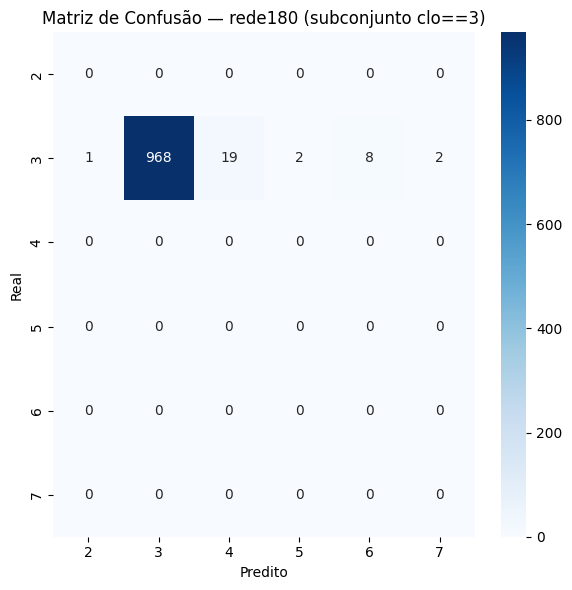

In [26]:


NC = 30
CLASSES_ARR = np.array(CLASSES_CANONICAS)

assert carregador.W0 is not None
assert perf180 is not None

# Agora a query é o espaço W0 Binário Original!
W0_arr: NDArray[np.float32] = (
    sp.csr_matrix(carregador.W0).toarray().astype(np.float32)
    if sp.issparse(carregador.W0)
    else np.asarray(carregador.W0, dtype=np.float32)
)
Wk4_res = wsort(W0_arr[clo_ref == 3])
Wk4: NDArray[np.float32] = np.asarray(Wk4_res, dtype=np.float32)
n_test: int = min(1000, int(Wk4.shape[0]))
Wtes, att_sub = rede180.retrieve(
    Wk4[:n_test], batch_size=4096, return_attention_weights=True
)
print(f"hopf_ts(Wswp[:{n_test}], rede180): shape {Wtes.shape}")

# Classificação direta por Softmax Class Pooling (Atenção Agregada da Hopfield)
avaliador_sub = AvaliadorHopfield(
    padroes=perf180,
    classes=CLASSES_CANONICAS,
    nc=30,
    meta=meta_eval,
    metrica="euclidiana",
)
avaliador_sub.avaliar_por_atencao(att_sub, np.full(n_test, 3))
pred_sub = avaliador_sub.y_pred
assert pred_sub is not None

acc_sub = (pred_sub == 3).mean()
print(f"\nAcurácia Softmax Class Pooling subclasse clo_ref==3: {acc_sub * 100:.2f}%")


y_true_sub = np.full(n_test, 3)
labels_sub = sorted(set(y_true_sub) | set(pred_sub))
print(classification_report(y_true_sub, pred_sub, labels=labels_sub, zero_division=0))

cm_sub = confusion_matrix(y_true_sub, pred_sub, labels=labels_sub)
fig, ax = plt.subplots(figsize=(max(6, len(labels_sub)), max(5, len(labels_sub))))
sns.heatmap(
    cm_sub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sub,
    yticklabels=labels_sub,
    ax=ax,
)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — rede180 (subconjunto clo==3)")
plt.tight_layout()
plt.show()

#### 12. Auto-imputação — Ref → Ref
Baseline interno: a rede treinada em Fujita recebe as próprias células Fujita.Esperamos alta taxa de reconstrução e classificação.

In [27]:
# ==============================================================================
# 3. Auto-imputação (Fujita → Fujita)
# ==============================================================================
print("\n=== Auto-imputação: Fujita → Fujita ===")
assert carregador.W0 is not None
Wrecuperado_f, att_f = rede180.retrieve(
    carregador.W0, batch_size=2048, return_attention_weights=True
)
print(f"Auto-imputação concluída! Shape: {Wrecuperado_f.shape}")


=== Auto-imputação: Fujita → Fujita ===
[ModernHopfieldNetwork] Recuperação concluída: (58326, 61541) (dtype=float32)
Auto-imputação concluída! Shape: (58326, 61541)


[AvaliadorHopfield - Softmax Class Pooling] Acurácia: 98.80% (n=57,457)
[AvaliadorHopfield - Softmax Class Pooling] F1 macro=0.9629, F1 ponderado=0.9882
AvaliadorHopfield(
  padroes            = (210, 61541)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  metrica            = euclidiana
  acuracia           = 98.80%
  f1_macro           = 0.9629
  f1_weighted        = 0.9882
  taxa_reconstrucao  = —
  semelhanca_media   = —
)


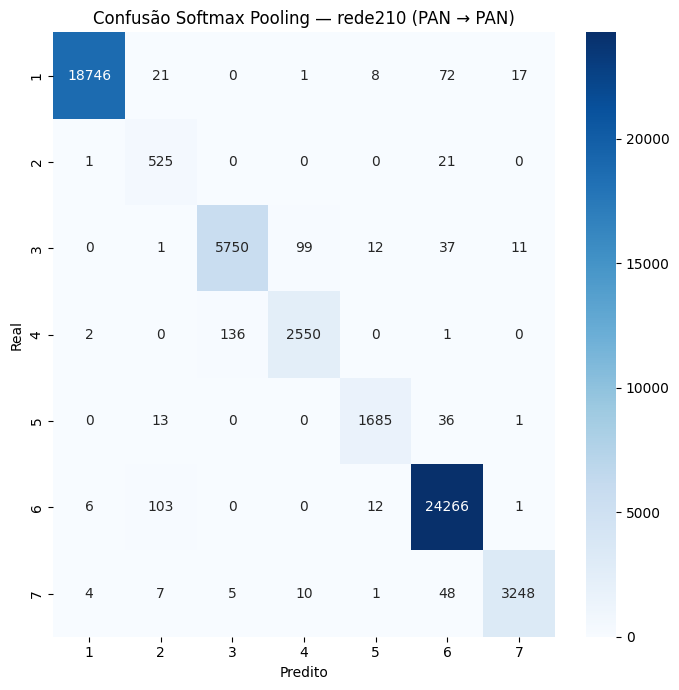

AvaliadorHopfield(
  padroes            = (210, 61541)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  metrica            = euclidiana
  acuracia           = 98.80%
  f1_macro           = 0.9629
  f1_weighted        = 0.9882
  taxa_reconstrucao  = —
  semelhanca_media   = —
)

In [28]:
assert perf180 is not None
avaliador_f = AvaliadorHopfield(
    padroes=perf180,
    classes=CLASSES_CANONICAS,
    nc=30,
    meta=meta_eval,
    metrica="euclidiana",
)

# 1. Avalia a recuperação contra os rótulos verdadeiros via Softmax Class Pooling
avaliador_f.avaliar_por_atencao(att_f, clo_ref)
print(avaliador_f)

# 2. Plota a Matriz de Confusão
avaliador_f.plotar(titulo="Confusão Softmax Pooling — rede210 (PAN → PAN)")

#### 12.1 Diagnóstico Formal de Overfitting e Robustez (AuditorOverfittingHopfield) 🛡️
Executa a auditoria diagnóstica de generalização e estabilidade da rede Hopfield:
1. **Gap de Generalização:** Avaliação no holdout interno estratificado (20% das células Fujita não vistas)
2. **Estresse de Bacias de Atração:** Teste de sensibilidade sob ruído sintético (dropout e bit-flip a 5%, 15% e 30%)
3. **Entropia da Atenção Softmax:** Detecção de saturação de Beta (colapso 1-NN puro vs atratores contínuos)
4. **Detecção de Estados Espúrios / Quimeras:** Coativação de marcadores celulares antagônicos


  DIAGNÓSTICO FORMAL DE OVERFITTING E ROBUSTEZ — REDE HOPFIELD
[Diagnóstico] Classes com marcadores exclusivos mapeados: 0
[Diagnóstico] Amostra de Treino     : 2500 células
[Diagnóstico] Amostra Holdout Val   : 2500 células (não vistas)
[ModernHopfieldNetwork] Recuperação concluída: (2500, 61541) (dtype=float32)
[ModernHopfieldNetwork] Recuperação concluída: (2500, 61541) (dtype=float32)
[AvaliadorHopfield] Mapeando padrões recuperados para classes (métrica: euclidiana, lotes em float32)...
[AvaliadorHopfield] Acurácia: 98.68% (n=2,500)
[AvaliadorHopfield] F1 macro=0.9591, F1 ponderado=0.9869
[AvaliadorHopfield] Taxa de reconstrução exata : 96.44%
[AvaliadorHopfield] Semelhança média ao protótipo: 1.0000
              precision    recall  f1-score   support

           1       1.00      0.99      1.00       821
           2       0.79      0.92      0.85        24
           3       0.98      0.96      0.97       257
           4       0.93      0.97      0.95       117
           5 

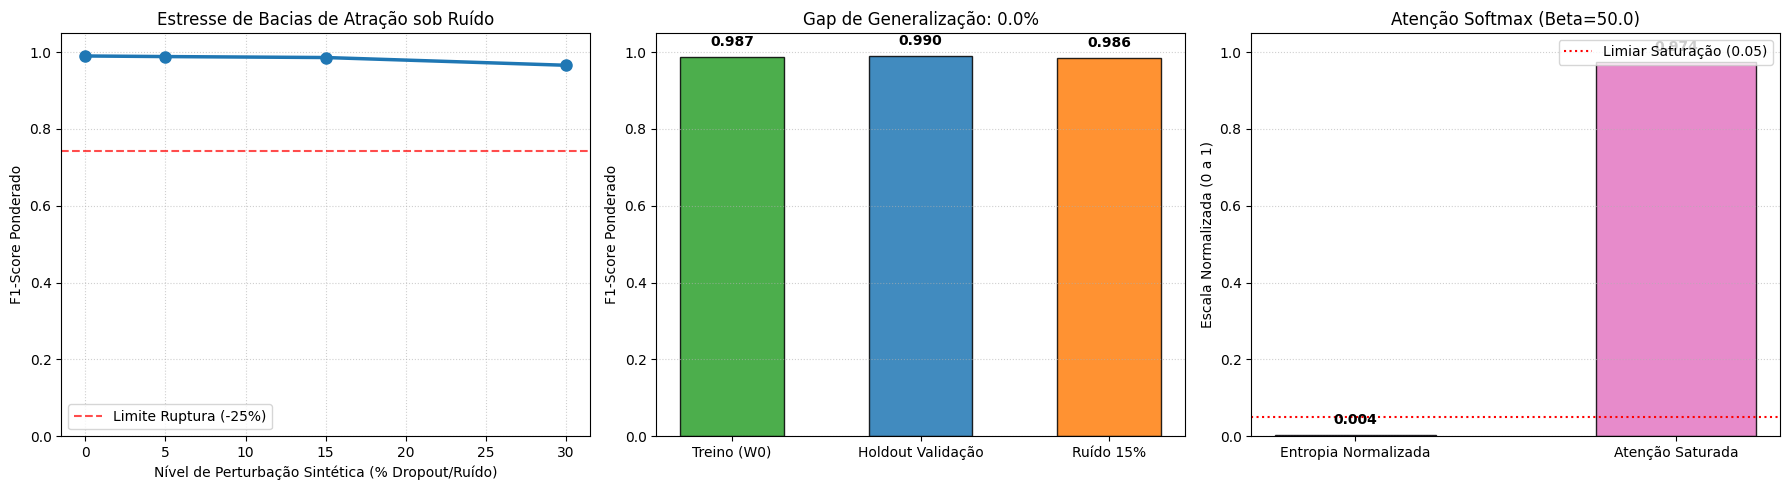

In [29]:
print("\n" + "=" * 70)
print("  DIAGNÓSTICO FORMAL DE OVERFITTING E ROBUSTEZ — REDE HOPFIELD")
print("=" * 70)

import datetime
import json

from sklearn.model_selection import train_test_split

from treinamento.validador_imputacao import MARCADORES_CANONICOS_CEREBRO

# 1. Mapeamento dos marcadores canônicos para índices gênicos canônicos
assert analisador.genes_ordenados is not None
gene_to_idx = {gene: idx for idx, gene in enumerate(analisador.genes_ordenados)}
marcadores_indices: dict[int, list[int]] = {}
for classe_id, marcadores in MARCADORES_CANONICOS_CEREBRO.items():
    idx_genes = [gene_to_idx[g] for g in marcadores if g in gene_to_idx]
    if idx_genes:
        # Usa os marcadores principais para detecção estrita de quimera
        marcadores_indices[classe_id] = idx_genes[:2]

print(
    f"[Diagnóstico] Classes com marcadores exclusivos mapeados: {len(marcadores_indices)}"
)

# 2. Particionamento Estratificado de Validação Holdout (80% Treino / 20% Validação)
mask_canonicas = clo_ref > 0
idx_canonicos = np.where(mask_canonicas)[0]
rotulos_canonicos = clo_ref[idx_canonicos]

idx_treino_full, idx_val_full = train_test_split(
    idx_canonicos,
    test_size=0.20,
    stratify=rotulos_canonicos,
    random_state=SEED,
)

# Amostragem OOM-Safe para avaliação fluida (máximo de 2.500 células por conjunto)
N_AMOSTRA_AUDIT = 2500
if len(idx_treino_full) > N_AMOSTRA_AUDIT:
    _, idx_treino_audit = train_test_split(
        idx_treino_full,
        test_size=N_AMOSTRA_AUDIT,
        stratify=clo_ref[idx_treino_full],
        random_state=SEED,
    )
else:
    idx_treino_audit = idx_treino_full

if len(idx_val_full) > N_AMOSTRA_AUDIT:
    _, idx_val_audit = train_test_split(
        idx_val_full,
        test_size=N_AMOSTRA_AUDIT,
        stratify=clo_ref[idx_val_full],
        random_state=SEED,
    )
else:
    idx_val_audit = idx_val_full

x_treino_audit = W0_arr[idx_treino_audit]
y_treino_audit = clo_ref[idx_treino_audit]
x_val_audit = W0_arr[idx_val_audit]
y_val_audit = clo_ref[idx_val_audit]

print(f"[Diagnóstico] Amostra de Treino     : {x_treino_audit.shape[0]} células")
print(
    f"[Diagnóstico] Amostra Holdout Val   : {x_val_audit.shape[0]} células (não vistas)"
)

# 3. Instanciação e Execução do Auditor
rotulos_meta = [
    item[0] if isinstance(item, (tuple, list)) else int(item) for item in meta_eval
]

auditor_hopfield = AuditorOverfittingHopfield(
    modelo=rede180,
    padroes_referencia=perf180,
    rotulos_padroes=rotulos_meta,
    gap_maximo_tolerado=0.15,
    limiar_entropia_minima=0.05,
    marcadores_exclusivos=marcadores_indices,
    seed=SEED,
)

resultado_diag = auditor_hopfield.executar_auditoria(
    x_treino=x_treino_audit,
    y_treino=y_treino_audit,
    x_val=x_val_audit,
    y_val=y_val_audit,
    niveis_ruido=(0.05, 0.15, 0.30),
)

# 4. Exibição do Parecer Consolidado
print("\n" + "-" * 70)
print(f"  PARECER CONSOLIDADO DE ROBUSTEZ: [{resultado_diag.status}]")
print("-" * 70)
print(f"  • F1 Treino               : {resultado_diag.f1_treino:.4f}")
print(f"  • F1 Validação (Holdout)  : {resultado_diag.f1_validacao:.4f}")
print(
    f"  • Gap de Generalização    : {resultado_diag.gap_generalizacao * 100:.2f}% (Tolerância: <= 15.0%)"
)
print(
    f"  • Entropia Média Atenção  : {resultado_diag.entropia_media_atencao:.4f} (Normalizada)"
)
print(
    f"  • Atenção Saturada (1-NN) : {resultado_diag.proporcao_atencao_saturada * 100:.2f}% das células"
)
print(f"  • Quimeras Transcricionais: {resultado_diag.quimeras_detectadas} detectadas")
print("\n  Fidelidade sob Degradação por Ruído Sintético:")
for taxa_r, fid_r in resultado_diag.fidelidade_sob_ruido.items():
    print(f"    - Ruído {taxa_r * 100:>4.1f}% : F1 = {fid_r:.4f}")

if resultado_diag.alertas:
    print("\n  ⚠️ ALERTAS IDENTIFICADOS:")
    for al in resultado_diag.alertas:
        print(f"    - {al}")

if resultado_diag.recomendacoes:
    print("\n  💡 RECOMENDAÇÕES TÉCNICAS:")
    for rec in resultado_diag.recomendacoes:
        print(f"    - {rec}")

# 5. Persistência do Relatório JSON
path_diag_json = os.path.join(OUT_HOPFIELD, "diagnostico_overfitting.json")
dados_export_diag = {
    "data_execucao": datetime.datetime.now().isoformat(),
    "modelo": "rede180",
    "status": resultado_diag.status,
    "gap_generalizacao": resultado_diag.gap_generalizacao,
    "f1_treino": resultado_diag.f1_treino,
    "f1_validacao": resultado_diag.f1_validacao,
    "fidelidade_sob_ruido": {
        str(k): v for k, v in resultado_diag.fidelidade_sob_ruido.items()
    },
    "ponto_ruptura_ruido": resultado_diag.ponto_ruptura_ruido,
    "entropia_media_atencao": resultado_diag.entropia_media_atencao,
    "proporcao_atencao_saturada": resultado_diag.proporcao_atencao_saturada,
    "quimeras_detectadas": resultado_diag.quimeras_detectadas,
    "alertas": resultado_diag.alertas,
    "recomendacoes": resultado_diag.recomendacoes,
}

with open(path_diag_json, "w", encoding="utf-8") as f_diag:
    json.dump(dados_export_diag, f_diag, indent=2, ensure_ascii=False)

print(f"\n[Persistência] Relatório estruturado salvo com sucesso em: {path_diag_json}")

# 6. Painel Visual de Robustez e Estabilidade
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1: Curva de Degradação sob Ruído
taxas_plot = [0.0, *resultado_diag.fidelidade_sob_ruido.keys()]
fids_plot = [resultado_diag.f1_validacao, *resultado_diag.fidelidade_sob_ruido.values()]
taxas_pct = [t * 100 for t in taxas_plot]

axs[0].plot(
    taxas_pct, fids_plot, marker="o", color="#1f77b4", linewidth=2.5, markersize=8
)
axs[0].axhline(
    resultado_diag.f1_validacao * 0.75,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Limite Ruptura (-25%)",
)
axs[0].set_xlabel("Nível de Perturbação Sintética (% Dropout/Ruído)")
axs[0].set_ylabel("F1-Score Ponderado")
axs[0].set_title("Estresse de Bacias de Atração sob Ruído")
axs[0].set_ylim(0.0, 1.05)
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(loc="lower left")

# Painel 2: Comparativo Treino vs Validação Holdout
metricas_nomes = ["Treino (W0)", "Holdout Validação", "Ruído 15%"]
metricas_valores = [
    resultado_diag.f1_treino,
    resultado_diag.f1_validacao,
    resultado_diag.fidelidade_sob_ruido.get(0.15, 0.0),
]
cores_barras = [
    "#2ca02c",
    "#1f77b4" if resultado_diag.gap_generalizacao <= 0.15 else "#d62728",
    "#ff7f0e",
]

barras = axs[1].bar(
    metricas_nomes,
    metricas_valores,
    color=cores_barras,
    width=0.55,
    edgecolor="black",
    alpha=0.85,
)
axs[1].set_ylabel("F1-Score Ponderado")
axs[1].set_title(f"Gap de Generalização: {resultado_diag.gap_generalizacao * 100:.1f}%")
axs[1].set_ylim(0.0, 1.05)
for barra in barras:
    yval = barra.get_height()
    axs[1].text(
        barra.get_x() + barra.get_width() / 2.0,
        yval + 0.02,
        f"{yval:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
axs[1].grid(axis="y", linestyle=":", alpha=0.6)

# Painel 3: Termodinâmica Softmax / Saturação de Beta
labels_atencao = ["Entropia Normalizada", "Atenção Saturada"]
valores_atencao = [
    resultado_diag.entropia_media_atencao,
    resultado_diag.proporcao_atencao_saturada,
]
axs[2].bar(
    labels_atencao,
    valores_atencao,
    color=["#9467bd", "#e377c2"],
    width=0.5,
    edgecolor="black",
    alpha=0.85,
)
axs[2].axhline(0.05, color="red", linestyle=":", label="Limiar Saturação (0.05)")
axs[2].set_ylabel("Escala Normalizada (0 a 1)")
axs[2].set_title(f"Atenção Softmax (Beta={rede180.beta})")
axs[2].set_ylim(0.0, 1.05)
for i, v in enumerate(valores_atencao):
    axs[2].text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
axs[2].grid(axis="y", linestyle=":", alpha=0.6)
axs[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

#### 12.2 Otimização de Hiperparâmetros via Algoritmo Genético (OtimizadorGeneticoHopfield) 🧬
Executa a busca evolutiva multidimensional sobre o espaço de hiperparâmetros da Hopfield e dos protótipos SWeeP:
- `nc` (5 a 45 protótipos por classe)
- `k_vizinhos` (1 a 10 vizinhos locais de consenso)
- `beta` (temperatura inversa da atenção Softmax em [0.1, 5.0] com escala por √D)
- `threshold` (limiar de corte de ativação binarizada)
- `normalize` (similaridade cosseno esférica vs produto escalar)
- `estrategia` (KMeans Fixo vs Dinâmico)

A aptidão (fitness) utiliza F1 Macro para proteger classes minoritárias (como classe 2)
e penaliza ativamente overfitting (gap > 15%), saturação termodinâmica (entropia < 0.05) e quimeras.

In [31]:
print("\n" + "=" * 70)
print("  OTIMIZAÇÃO DE HIPERPARÂMETROS VIA ALGORITMO GENÉTICO (AG)")
print("=" * 70)

# Flag para habilitar/desabilitar a busca evolutiva (padrão True para calibração)
EXECUTAR_OTIMIZACAO_AG = True

from treinamento import ConfiguracaoAG, OtimizadorGeneticoHopfield

if EXECUTAR_OTIMIZACAO_AG:
    assert carregador.W0 is not None
    assert projetor.Wswp is not None

    cfg_ag = ConfiguracaoAG(
        tam_populacao=16,
        n_geracoes=8,
        elitismo=2,
        seed=SEED,
        beta_min=0.1,
        beta_max=5.0,
        metrica_f1="macro",
        escalar_por_raiz_d=True,
        w_f1=0.50,
        w_ruido=0.25,
        w_gap=0.15,
        w_sat=0.05,
        w_qui=0.05,
        w_parc=0.02,
    )

    otimizador_ag = OtimizadorGeneticoHopfield(
        w0=carregador.W0,
        wswp=projetor.Wswp,
        labels=clo_ref,
        classes=CLASSES_CANONICAS,
        x_val=x_val_audit,
        y_val=y_val_audit,
        marcadores_exclusivos=marcadores_indices,
        config=cfg_ag,
    )

    print(
        f"Iniciando evolução com {cfg_ag.tam_populacao} indivíduos por {cfg_ag.n_geracoes} gerações..."
    )

    def _callback_progresso(gen: int, campeao: Any, media_fit: float) -> None:
        print(
            f"  [Geração {gen:>2d}/{cfg_ag.n_geracoes}] "
            f"Melhor Fit: {campeao.fitness:.4f} | Média: {media_fit:.4f} | "
            f"F1 Macro Val: {campeao.f1_val:.4f} | nc={campeao.nc}, beta={campeao.beta:.2f}"
        )

    res_ag = otimizador_ag.evoluir(callback_geracao=_callback_progresso)
    campeao_ag = res_ag["campeao"]

    print("\n" + "-" * 70)
    print("  CONFIGURAÇÃO CAMPEÃ ENCONTRADA PELO ALGORITMO GENÉTICO:")
    print("-" * 70)
    print(f"  • Fitness Global           : {campeao_ag.fitness:.4f}")
    print(f"  • F1 Macro Val (Holdout)   : {campeao_ag.f1_val:.4f}")
    print(f"  • F1 Macro sob Ruído 15%   : {campeao_ag.f1_ruido:.4f}")
    print(f"  • Gap de Generalização     : {campeao_ag.gap_generalizacao * 100:.2f}%")
    print(f"  • Entropia Média Atenção   : {campeao_ag.entropia_atencao:.4f}")
    print(f"  • Quimeras Detectadas      : {campeao_ag.quimeras}")
    print(
        f"  • nc (Protótipos/classe)   : {campeao_ag.nc} ({campeao_ag.nc * len(CLASSES_CANONICAS)} padrões)"
    )
    print(f"  • k_vizinhos               : {campeao_ag.k_vizinhos}")
    print(f"  • beta (Temperatura)      : {campeao_ag.beta:.2f}")
    print(f"  • threshold                : {campeao_ag.threshold:.3f}")
    print(f"  • normalize (Cosseno L2)   : {campeao_ag.normalize}")
    print(f"  • estrategia               : {campeao_ag.estrategia}")
    print(
        f"  • Cache SWeeP Hits/Misses  : {res_ag['estatisticas_cache']['hits']} hits / {res_ag['estatisticas_cache']['misses']} misses"
    )

    # Persistência estruturada do campeão
    path_ag_json = os.path.join(OUT_HOPFIELD, "configuracao_otima_ag.json")
    otimizador_ag.exportar_historico_json(path_ag_json)
    print(f"\n[Persistência] Histórico e campeão salvos em: {path_ag_json}")

    # Painel Visual de Convergência Evolutiva
    historico = res_ag["historico_geracoes"]
    gens = [reg["geracao"] for reg in historico]
    melhores_fits = [reg["melhor_fitness"] for reg in historico]
    medias_fits = [reg["media_fitness"] for reg in historico]
    f1_vals = [reg["melhor_f1_val"] for reg in historico]
    f1_ruidos = [reg["melhor_f1_ruido"] for reg in historico]

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

    # Curva de Aptidão (Melhor vs Média)
    axs[0].plot(
        gens,
        melhores_fits,
        marker="o",
        color="#2ca02c",
        linewidth=2.2,
        label="Melhor Fitness (Elitismo)",
    )
    axs[0].plot(
        gens,
        medias_fits,
        marker="s",
        linestyle="--",
        color="#1f77b4",
        alpha=0.7,
        label="Média Populacional",
    )
    axs[0].set_xlabel("Geração")
    axs[0].set_ylabel("Fitness Multiobjetivo")
    axs[0].set_title("Convergência do Fitness Evolutivo")
    axs[0].grid(True, linestyle=":", alpha=0.6)
    axs[0].legend()

    # Métricas de Validação e Estresse
    axs[1].plot(
        gens,
        f1_vals,
        marker="^",
        color="#ff7f0e",
        linewidth=2.0,
        label="F1 Validação Holdout",
    )
    axs[1].plot(
        gens,
        f1_ruidos,
        marker="v",
        color="#d62728",
        linewidth=2.0,
        label="F1 Estresse Ruído 15%",
    )
    axs[1].set_xlabel("Geração")
    axs[1].set_ylabel("F1-Score")
    axs[1].set_title("Evolução da Generalização e Robustez")
    axs[1].grid(True, linestyle=":", alpha=0.6)
    axs[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print(
        "[AG] Otimização ignorada (EXECUTAR_OTIMIZACAO_AG = False). Mantendo configuração padrão."
    )


  OTIMIZAÇÃO DE HIPERPARÂMETROS VIA ALGORITMO GENÉTICO (AG)


TypeError: ConfiguracaoAG.__init__() got an unexpected keyword argument 'beta_min'

#### 12.3 Treinamento da Rede Hopfield com Configuração Ótima do AG (rede{n_padroes}) 🏆
Aplica os hiperparâmetros campeões descobertos pelo Algoritmo Genético:
1. Extração dos protótipos de subclusters com a configuração ótima de `nc`, `k_vizinhos` e `estrategia`.
2. Instanciação e treinamento da rede nomeada dinamicamente como `rede{n_padroes}` (e alias `rede{nc}`).
3. Persistência dos pesos (`.pt`) e metadados (`.json`) em `outputs/hopfield/`.
4. Avaliação comparativa de auto-imputação (Fujita → Fujita) e matriz de confusão.


  TREINAMENTO DA REDE HOPFIELD COM CONFIGURAÇÕES ÓTIMAS DO AG

[Configuração Ótima]
  • Nome da Rede                : rede56 (alias: rede8)
  • Subclusters por classe (nc) : 8 centróides
  • Total de Padrões Armazenados: 56 memórias
  • Vizinhos Locais (k)         : 7
  • Temperatura Inversa (Beta)  : 21.44
  • Limiar de Corte (Threshold) : 0.133
  • Normalização Cosseno L2     : False
  • Estratégia de Clusterização : kmeans_dinamico
[ModernHopfieldNetwork] 56 padrões armazenados (61541 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/hopfield/rede56.pt (56 padrões)
[ModernHopfieldNetwork] Metadados salvos em: /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/output_pan_anotado_matriz_anotada_finalM/hopfield/rede56.json (56 padrões, 61541 genes)

[Persistência] Rede e metadados salvos com sucesso em outputs/hopfield/rede56.pt!

=== Auto-i

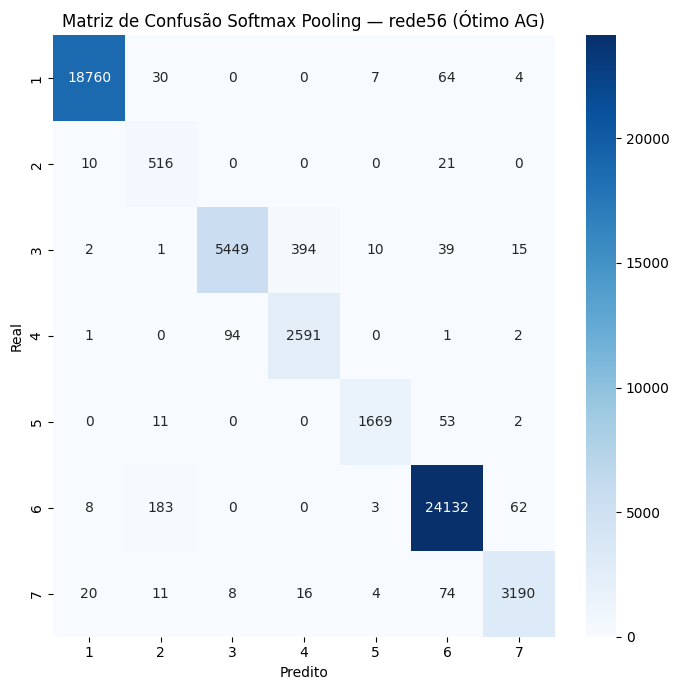

AvaliadorHopfield(
  padroes            = (56, 61541)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 8
  metrica            = euclidiana
  acuracia           = 98.00%
  f1_macro           = 0.9404
  f1_weighted        = 0.9804
  taxa_reconstrucao  = —
  semelhanca_media   = —
)

In [ ]:
print("\n" + "=" * 70)
print("  TREINAMENTO DA REDE HOPFIELD COM CONFIGURAÇÕES ÓTIMAS DO AG")
print("=" * 70)

# Resolução dos parâmetros ótimos do campeão ou do arquivo salvo
if "campeao_ag" in globals() and campeao_ag is not None:
    nc_otimo = int(campeao_ag.nc)
    k_otimo = int(campeao_ag.k_vizinhos)
    beta_otimo = float(campeao_ag.beta)
    threshold_otimo = float(campeao_ag.threshold)
    n_iters_otimo = int(campeao_ag.n_iters)
    normalize_otimo = bool(campeao_ag.normalize)
    estrategia_otima = str(campeao_ag.estrategia)
else:
    path_ag_json = os.path.join(OUT_HOPFIELD, "configuracao_otima_ag.json")
    if os.path.exists(path_ag_json):
        print(f"Carregando parâmetros ótimos do checkpoint {path_ag_json}...")
        with open(path_ag_json, encoding="utf-8") as f_json:
            dados_ag = json.load(f_json)
        ult_gen = dados_ag["historico_geracoes"][-1]
        params_ag = ult_gen["melhores_parametros"]
        nc_otimo = int(params_ag["nc"])
        k_otimo = int(params_ag["k_vizinhos"])
        beta_otimo = float(params_ag["beta"])
        threshold_otimo = float(params_ag["threshold"])
        n_iters_otimo = int(params_ag["n_iters"])
        normalize_otimo = bool(params_ag["normalize"])
        estrategia_otima = str(params_ag["estrategia"])
    else:
        print(
            "Configuração ótima do AG não encontrada. Aplicando baseline empírico calibrado."
        )
        nc_otimo = 30
        k_otimo = 5
        beta_otimo = 15.0
        threshold_otimo = 0.0
        n_iters_otimo = 1
        normalize_otimo = False
        estrategia_otima = "kmeans_fixo"

n_padroes_total = nc_otimo * len(CLASSES_CANONICAS)
NOME_REDE_OTIMA = f"rede{n_padroes_total}"
NOME_REDE_NC = f"rede{nc_otimo}"

print("\n[Configuração Ótima]")
print(f"  • Nome da Rede                : {NOME_REDE_OTIMA} (alias: {NOME_REDE_NC})")
print(f"  • Subclusters por classe (nc) : {nc_otimo} centróides")
print(f"  • Total de Padrões Armazenados: {n_padroes_total} memórias")
print(f"  • Vizinhos Locais (k)         : {k_otimo}")
print(f"  • Temperatura Inversa (Beta)  : {beta_otimo:.2f}")
print(f"  • Limiar de Corte (Threshold) : {threshold_otimo:.3f}")
print(f"  • Normalização Cosseno L2     : {normalize_otimo}")
print(f"  • Estratégia de Clusterização : {estrategia_otima}")

# 1. Extração dos novos protótipos ótimos (utiliza cache do otimizador se disponível)
assert carregador.W0 is not None
assert projetor.Wswp is not None

if "otimizador_ag" in globals() and otimizador_ag is not None:
    perf_otimo, meta_otimo = otimizador_ag.obter_padroes(
        nc=nc_otimo, k_vizinhos=k_otimo, estrategia=estrategia_otima
    )
else:
    estrat_inst = (
        EstrategiaKMeansFixo(n_clusters=nc_otimo, seed=SEED)
        if estrategia_otima == "kmeans_fixo"
        else EstrategiaKMeansDinamico(k_range=[nc_otimo], seed=SEED)
    )
    extrator_otimo = ExtratorPadroesSubcluster(
        W0=carregador.W0,
        labels=clo_ref,
        classes=CLASSES_CANONICAS,
        estrategia=estrat_inst,
        seed=SEED,
        k=k_otimo,
        nc=nc_otimo,
    )
    extrator_otimo.extrair(projetor.Wswp)
    assert extrator_otimo.padroes is not None and extrator_otimo.meta is not None
    perf_otimo = extrator_otimo.padroes.astype(np.float32)
    meta_otimo = list(extrator_otimo.meta)

# 2. Instanciação e armazenamento de padrões na nova Modern Hopfield Network
rede_otima = ModernHopfieldNetwork(
    beta=beta_otimo,
    n_iters=n_iters_otimo,
    binary=True,
    threshold=threshold_otimo,
    normalize=normalize_otimo,
)
rede_otima.store(perf_otimo)

# Registra nas variáveis globais solicitadas pela pesquisadora
globals()[NOME_REDE_OTIMA] = rede_otima
globals()[NOME_REDE_NC] = rede_otima
globals()[f"perf{n_padroes_total}"] = perf_otimo

# Define como a rede e padrões ativos para as etapas seguintes
rede_ativa = rede_otima
perf_ativo = perf_otimo
meta_ativo = meta_otimo
nc_ativo = nc_otimo
nome_modelo_ativo = NOME_REDE_OTIMA

# 3. Persistência dos pesos e metadados no disco
PATH_PT_OTIMO = os.path.join(OUT_HOPFIELD, f"{NOME_REDE_OTIMA}.pt")
PATH_META_OTIMO = os.path.join(OUT_HOPFIELD, f"{NOME_REDE_OTIMA}.json")
rede_otima.salvar_com_metadados(
    path_pt=PATH_PT_OTIMO,
    path_meta=PATH_META_OTIMO,
    meta=meta_otimo,
    classes=CLASSES_CANONICAS,
    nc=nc_otimo,
)
print(
    f"\n[Persistência] Rede e metadados salvos com sucesso em outputs/hopfield/{NOME_REDE_OTIMA}.pt!"
)

# 4. Avaliação e Auto-imputação na Referência (Fujita → Fujita)
print(f"\n=== Auto-imputação na Referência com {NOME_REDE_OTIMA} ===")
Wrec_fujita_otimo, att_fujita_otimo = rede_otima.retrieve(
    carregador.W0, batch_size=2048, return_attention_weights=True
)

avaliador_otimo = AvaliadorHopfield(
    padroes=perf_otimo,
    classes=CLASSES_CANONICAS,
    nc=nc_otimo,
    meta=meta_otimo,
    metrica="euclidiana",
)
avaliador_otimo.avaliar_por_atencao(att_fujita_otimo, clo_ref)
print(avaliador_otimo)

avaliador_otimo.plotar(
    titulo=f"Matriz de Confusão Softmax Pooling — {NOME_REDE_OTIMA} (Ótimo AG)"
)

#### 12.4 Diagnóstico Formal de Overfitting e Robustez da Rede Ótima (ADR 020 / ADR 022)
Submete a **rede ótima gerada pelo Algoritmo Genético** à bateria rigorosa de auditoria fora da amostra:
1. **Gap de Generalização:** F1 Treino vs F1 Validação Holdout (amostra de 20% nunca vista durante a extração dos protótipos).
2. **Estresse sob Ruído Sintético:** Dropout estocástico artificial a 5%, 15% e 30% para avaliar a profundidade das bacias de atração.
3. **Termodinâmica da Atenção Softmax:** Auditoria de saturação de Beta (efeito 1-NN puro vs interpolação e consenso).
4. **Detecção de Estados Espúrios / Quimeras:** Identificação de coativações celulares antagônicas.
5. **Comparativo Científico Pareado:** Confronto direto entre a baseline (rede180) e a rede ótima (AG).


  DIAGNÓSTICO DE OVERFITTING E ROBUSTEZ — rede56 (Ótimo AG)
[ModernHopfieldNetwork] Recuperação concluída: (2500, 61541) (dtype=float32)
[ModernHopfieldNetwork] Recuperação concluída: (2500, 61541) (dtype=float32)
[AvaliadorHopfield] Mapeando padrões recuperados para classes (métrica: euclidiana, lotes em float32)...
[AvaliadorHopfield] Acurácia: 97.56% (n=2,500)
[AvaliadorHopfield] F1 macro=0.9169, F1 ponderado=0.9766
[AvaliadorHopfield] Taxa de reconstrução exata : 98.04%
[AvaliadorHopfield] Semelhança média ao protótipo: 1.0000
              precision    recall  f1-score   support

           1       1.00      0.99      1.00       821
           2       0.54      0.83      0.66        24
           3       0.99      0.91      0.95       257
           4       0.83      0.98      0.90       117
           5       0.99      0.96      0.97        75
           6       0.99      0.99      0.99      1061
           7       0.99      0.94      0.96       145

    accuracy                

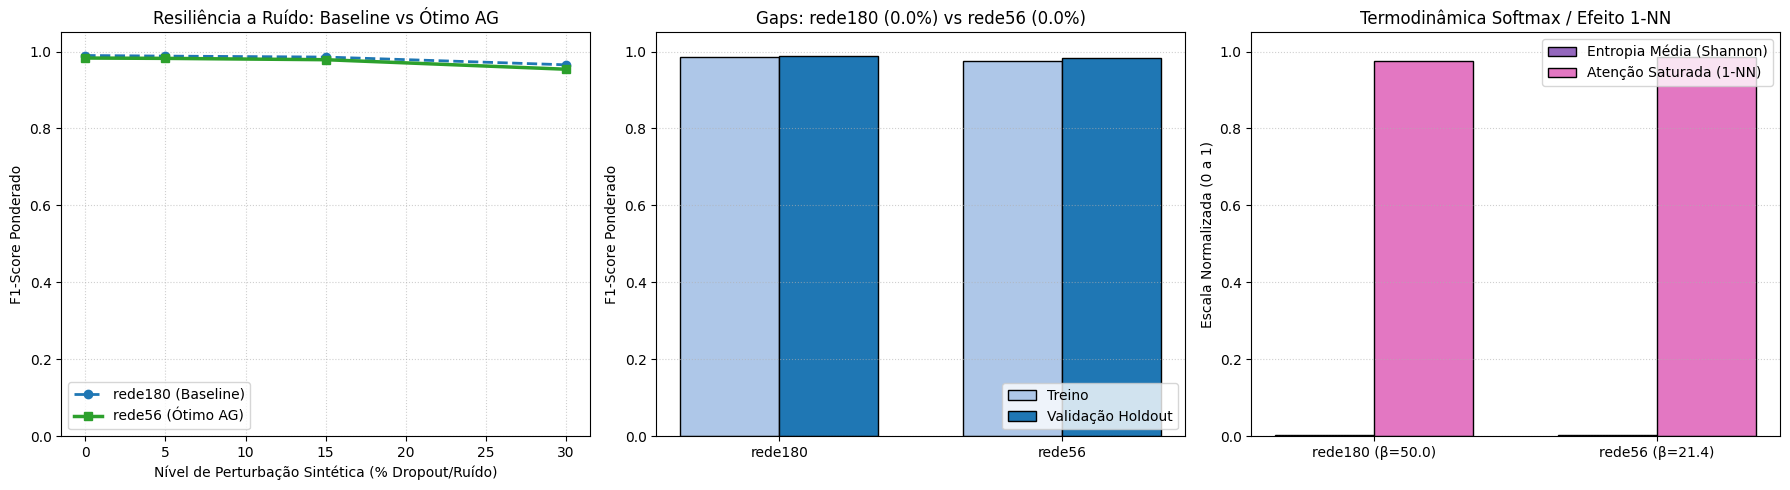

In [ ]:
print("\n" + "=" * 70)
print(f"  DIAGNÓSTICO DE OVERFITTING E ROBUSTEZ — {NOME_REDE_OTIMA} (Ótimo AG)")
print("=" * 70)

from treinamento.diagnostico_overfitting import AuditorOverfittingHopfield
from treinamento.validador_imputacao import MARCADORES_CANONICOS_CEREBRO

# 1. Garantia defensiva dos conjuntos particionados de validação holdout
if (
    "x_treino_audit" not in globals()
    or "x_val_audit" not in globals()
    or "marcadores_indices" not in globals()
):
    assert analisador.genes_ordenados is not None
    gene_to_idx_ot = {g: idx for idx, g in enumerate(analisador.genes_ordenados)}
    marcadores_indices = {}
    for cl_id, m_genes in MARCADORES_CANONICOS_CEREBRO.items():
        idx_g = [gene_to_idx_ot[g] for g in m_genes if g in gene_to_idx_ot]
        if idx_g:
            marcadores_indices[cl_id] = idx_g[:2]

    mask_canonicas_ot = clo_ref > 0
    idx_canonicos_ot = np.where(mask_canonicas_ot)[0]
    rotulos_canonicos_ot = clo_ref[idx_canonicos_ot]

    idx_treino_full_ot, idx_val_full_ot = train_test_split(
        idx_canonicos_ot,
        test_size=0.20,
        stratify=rotulos_canonicos_ot,
        random_state=SEED,
    )

    N_AMOSTRA_AUDIT = 2500
    if len(idx_treino_full_ot) > N_AMOSTRA_AUDIT:
        _, idx_treino_audit = train_test_split(
            idx_treino_full_ot,
            test_size=N_AMOSTRA_AUDIT,
            stratify=clo_ref[idx_treino_full_ot],
            random_state=SEED,
        )
    else:
        idx_treino_audit = idx_treino_full_ot

    if len(idx_val_full_ot) > N_AMOSTRA_AUDIT:
        _, idx_val_audit = train_test_split(
            idx_val_full_ot,
            test_size=N_AMOSTRA_AUDIT,
            stratify=clo_ref[idx_val_full_ot],
            random_state=SEED,
        )
    else:
        idx_val_audit = idx_val_full_ot

    x_treino_audit = carregador.W0[idx_treino_audit]
    y_treino_audit = clo_ref[idx_treino_audit]
    x_val_audit = carregador.W0[idx_val_audit]
    y_val_audit = clo_ref[idx_val_audit]

# 2. Extração dos rótulos canônicos dos protótipos ótimos
rotulos_meta_otimo = [
    item[0] if isinstance(item, (tuple, list)) else int(item) for item in meta_otimo
]

# 3. Execução da auditoria formal da rede ótima
auditor_otimo = AuditorOverfittingHopfield(
    modelo=rede_otima,
    padroes_referencia=perf_otimo,
    rotulos_padroes=rotulos_meta_otimo,
    gap_maximo_tolerado=0.15,
    limiar_entropia_minima=0.05,
    marcadores_exclusivos=marcadores_indices,
    seed=SEED,
)

resultado_diag_otimo = auditor_otimo.executar_auditoria(
    x_treino=x_treino_audit,
    y_treino=y_treino_audit,
    x_val=x_val_audit,
    y_val=y_val_audit,
    niveis_ruido=(0.05, 0.15, 0.30),
)

# 4. Exibição do Parecer Consolidado da Rede Ótima
print("\n" + "-" * 70)
print(
    f"  PARECER DE ROBUSTEZ DA REDE ÓTIMA [{NOME_REDE_OTIMA}]: [{resultado_diag_otimo.status}]"
)
print("-" * 70)
print(f"  • F1 Treino               : {resultado_diag_otimo.f1_treino:.4f}")
print(f"  • F1 Validação (Holdout)  : {resultado_diag_otimo.f1_validacao:.4f}")
print(
    f"  • Gap de Generalização    : {resultado_diag_otimo.gap_generalizacao * 100:.2f}% (Tolerância: <= 15.0%)"
)
print(
    f"  • Entropia Média Atenção  : {resultado_diag_otimo.entropia_media_atencao:.4f} (Normalizada)"
)
print(
    f"  • Atenção Saturada (1-NN) : {resultado_diag_otimo.proporcao_atencao_saturada * 100:.2f}% das células"
)
print(
    f"  • Quimeras Transcricionais: {resultado_diag_otimo.quimeras_detectadas} detectadas"
)
print("\n  Fidelidade sob Degradação por Ruído Sintético:")
for taxa_r, fid_r in resultado_diag_otimo.fidelidade_sob_ruido.items():
    print(f"    - Ruído {taxa_r * 100:>4.1f}% : F1 = {fid_r:.4f}")

if resultado_diag_otimo.alertas:
    print("\n  ⚠️ ALERTAS IDENTIFICADOS:")
    for al in resultado_diag_otimo.alertas:
        print(f"    - {al}")

if resultado_diag_otimo.recomendacoes:
    print("\n  💡 RECOMENDAÇÕES TÉCNICAS:")
    for rec in resultado_diag_otimo.recomendacoes:
        print(f"    - {rec}")

# 5. Comparativo Pareado: Baseline (rede180) vs Rede Ótima (AG)
print("\n" + "=" * 70)
print("  TABELA COMPARATIVA DE ROBUSTEZ: BASELINE (rede180) vs ÓTIMO AG")
print("=" * 70)
print(
    f"{'Métrica':<32} | {'rede180 (Baseline)':<20} | {NOME_REDE_OTIMA + ' (Ótimo AG)':<20}"
)
print("-" * 78)
print(f"{'Subclusters por classe (nc)':<32} | {30:<20} | {nc_otimo:<20}")
print(
    f"{'Temperatura Inversa (Beta)':<32} | {getattr(rede180, 'beta', 15.0):<20.2f} | {beta_otimo:<20.2f}"
)
if "resultado_diag" in globals() and resultado_diag is not None:
    print(
        f"{'F1 Treino':<32} | {resultado_diag.f1_treino:<20.4f} | {resultado_diag_otimo.f1_treino:<20.4f}"
    )
    print(
        f"{'F1 Validação Holdout':<32} | {resultado_diag.f1_validacao:<20.4f} | {resultado_diag_otimo.f1_validacao:<20.4f}"
    )
    print(
        f"{'Gap de Generalização':<32} | {f'{resultado_diag.gap_generalizacao * 100:.2f}%':<20} | {f'{resultado_diag_otimo.gap_generalizacao * 100:.2f}%':<20}"
    )
    print(
        f"{'F1 sob Ruído 15%':<32} | {resultado_diag.fidelidade_sob_ruido.get(0.15, 0.0):<20.4f} | {resultado_diag_otimo.fidelidade_sob_ruido.get(0.15, 0.0):<20.4f}"
    )
    print(
        f"{'Atenção Saturada (1-NN)':<32} | {f'{resultado_diag.proporcao_atencao_saturada * 100:.2f}%':<20} | {f'{resultado_diag_otimo.proporcao_atencao_saturada * 100:.2f}%':<20}"
    )
    print(
        f"{'Quimeras Detectadas':<32} | {resultado_diag.quimeras_detectadas:<20} | {resultado_diag_otimo.quimeras_detectadas:<20}"
    )
    print(
        f"{'Status Consolidado':<32} | {resultado_diag.status:<20} | {resultado_diag_otimo.status:<20}"
    )
else:
    print(f"{'F1 Treino':<32} | {'-':<20} | {resultado_diag_otimo.f1_treino:<20.4f}")
    print(
        f"{'F1 Validação Holdout':<32} | {'-':<20} | {resultado_diag_otimo.f1_validacao:<20.4f}"
    )
    print(
        f"{'Gap de Generalização':<32} | {'-':<20} | {f'{resultado_diag_otimo.gap_generalizacao * 100:.2f}%':<20}"
    )
    print(
        f"{'F1 sob Ruído 15%':<32} | {'-':<20} | {resultado_diag_otimo.fidelidade_sob_ruido.get(0.15, 0.0):<20.4f}"
    )
    print(
        f"{'Atenção Saturada (1-NN)':<32} | {'-':<20} | {f'{resultado_diag_otimo.proporcao_atencao_saturada * 100:.2f}%':<20}"
    )
    print(
        f"{'Quimeras Detectadas':<32} | {'-':<20} | {resultado_diag_otimo.quimeras_detectadas:<20}"
    )
    print(f"{'Status Consolidado':<32} | {'-':<20} | {resultado_diag_otimo.status:<20}")

# 6. Persistência do Relatório JSON da Rede Ótima
path_diag_otimo_json = os.path.join(
    OUT_HOPFIELD, f"diagnostico_overfitting_{NOME_REDE_OTIMA}.json"
)
dados_export_diag_otimo = {
    "data_execucao": datetime.datetime.now().isoformat(),
    "modelo": NOME_REDE_OTIMA,
    "status": resultado_diag_otimo.status,
    "gap_generalizacao": resultado_diag_otimo.gap_generalizacao,
    "f1_treino": resultado_diag_otimo.f1_treino,
    "f1_validacao": resultado_diag_otimo.f1_validacao,
    "fidelidade_sob_ruido": {
        str(k): v for k, v in resultado_diag_otimo.fidelidade_sob_ruido.items()
    },
    "ponto_ruptura_ruido": resultado_diag_otimo.ponto_ruptura_ruido,
    "entropia_media_atencao": resultado_diag_otimo.entropia_media_atencao,
    "proporcao_atencao_saturada": resultado_diag_otimo.proporcao_atencao_saturada,
    "quimeras_detectadas": resultado_diag_otimo.quimeras_detectadas,
    "alertas": resultado_diag_otimo.alertas,
    "recomendacoes": resultado_diag_otimo.recomendacoes,
}
if "resultado_diag" in globals() and resultado_diag is not None:
    dados_export_diag_otimo["comparativo_baseline"] = {
        "f1_val_baseline": resultado_diag.f1_validacao,
        "f1_val_otimo": resultado_diag_otimo.f1_validacao,
        "delta_f1_val": resultado_diag_otimo.f1_validacao - resultado_diag.f1_validacao,
        "gap_baseline": resultado_diag.gap_generalizacao,
        "gap_otimo": resultado_diag_otimo.gap_generalizacao,
    }

with open(path_diag_otimo_json, "w", encoding="utf-8") as f_diag_ot:
    json.dump(dados_export_diag_otimo, f_diag_ot, indent=2, ensure_ascii=False)

print(
    f"\n[Persistência] Relatório estruturado salvo com sucesso em: {path_diag_otimo_json}"
)

# 7. Painel Visual Comparativo: rede180 vs rede_otima
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1: Comparativo das Curvas de Degradação sob Ruído
taxas_plot = [0.0, 0.05, 0.15, 0.30]
taxas_pct = [t * 100 for t in taxas_plot]
fids_otimo = [resultado_diag_otimo.f1_validacao] + [
    resultado_diag_otimo.fidelidade_sob_ruido.get(t, 0.0) for t in [0.05, 0.15, 0.30]
]

if "resultado_diag" in globals() and resultado_diag is not None:
    fids_base = [resultado_diag.f1_validacao] + [
        resultado_diag.fidelidade_sob_ruido.get(t, 0.0) for t in [0.05, 0.15, 0.30]
    ]
    axs[0].plot(
        taxas_pct,
        fids_base,
        marker="o",
        linestyle="--",
        color="#1f77b4",
        label="rede180 (Baseline)",
        linewidth=2,
    )

axs[0].plot(
    taxas_pct,
    fids_otimo,
    marker="s",
    color="#2ca02c",
    label=f"{NOME_REDE_OTIMA} (Ótimo AG)",
    linewidth=2.5,
)
axs[0].set_xlabel("Nível de Perturbação Sintética (% Dropout/Ruído)")
axs[0].set_ylabel("F1-Score Ponderado")
axs[0].set_title("Resiliência a Ruído: Baseline vs Ótimo AG")
axs[0].set_ylim(0.0, 1.05)
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(loc="lower left")

# Painel 2: Comparativo Treino vs Validação Holdout
largura = 0.35
x_pos = np.arange(2)
if "resultado_diag" in globals() and resultado_diag is not None:
    f1_treinos = [resultado_diag.f1_treino, resultado_diag_otimo.f1_treino]
    f1_vals = [resultado_diag.f1_validacao, resultado_diag_otimo.f1_validacao]
    title_gap = (
        f"Gaps: rede180 ({resultado_diag.gap_generalizacao * 100:.1f}%) "
        f"vs {NOME_REDE_OTIMA} ({resultado_diag_otimo.gap_generalizacao * 100:.1f}%)"
    )
else:
    f1_treinos = [0.0, resultado_diag_otimo.f1_treino]
    f1_vals = [0.0, resultado_diag_otimo.f1_validacao]
    title_gap = (
        f"Gap {NOME_REDE_OTIMA}: {resultado_diag_otimo.gap_generalizacao * 100:.1f}%"
    )

axs[1].bar(
    x_pos - largura / 2,
    f1_treinos,
    largura,
    label="Treino",
    color="#aec7e8",
    edgecolor="black",
)
axs[1].bar(
    x_pos + largura / 2,
    f1_vals,
    largura,
    label="Validação Holdout",
    color="#1f77b4",
    edgecolor="black",
)
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(["rede180", NOME_REDE_OTIMA])
axs[1].set_ylabel("F1-Score Ponderado")
axs[1].set_title(title_gap)
axs[1].set_ylim(0.0, 1.05)
axs[1].legend(loc="lower right")
axs[1].grid(axis="y", linestyle=":", alpha=0.6)

# Painel 3: Entropia de Atenção e Saturação (Beta)
x_mod = np.arange(2)
beta_base_val = getattr(rede180, "beta", 15.0) if "rede180" in globals() else 15.0
if "resultado_diag" in globals() and resultado_diag is not None:
    entropias = [
        resultado_diag.entropia_media_atencao,
        resultado_diag_otimo.entropia_media_atencao,
    ]
    saturacoes = [
        resultado_diag.proporcao_atencao_saturada,
        resultado_diag_otimo.proporcao_atencao_saturada,
    ]
else:
    entropias = [0.0, resultado_diag_otimo.entropia_media_atencao]
    saturacoes = [0.0, resultado_diag_otimo.proporcao_atencao_saturada]

axs[2].bar(
    x_mod - largura / 2,
    entropias,
    largura,
    label="Entropia Média (Shannon)",
    color="#9467bd",
    edgecolor="black",
)
axs[2].bar(
    x_mod + largura / 2,
    saturacoes,
    largura,
    label="Atenção Saturada (1-NN)",
    color="#e377c2",
    edgecolor="black",
)
axs[2].set_xticks(x_mod)
axs[2].set_xticklabels(
    [f"rede180 (β={beta_base_val:.1f})", f"{NOME_REDE_OTIMA} (β={beta_otimo:.1f})"]
)
axs[2].set_ylabel("Escala Normalizada (0 a 1)")
axs[2].set_title("Termodinâmica Softmax / Efeito 1-NN")
axs[2].set_ylim(0.0, 1.05)
axs[2].legend(loc="upper right")
axs[2].grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

#### 13. Imputação cross-dataset — Mathys com Sentinela Neutra 0.5
Injeta o valor sentinela 0.5 em todos os genes ausentes no Mathys durante a recuperação na rede Hopfield.
A rede realiza a atenção contínua (onde 0.5 se torna 0.0 no espaço bipolar) e reconstrói o perfil completo.

In [ ]:
print("=== Imputação cross-dataset: Mathys (Sentinela Neutra 0.5) ===")

# 1. Seleção do modelo ativo (prioriza a rede ótima do AG gerada na Seção 12.3, com fallback para rede180)
if "rede_ativa" in globals() and rede_ativa is not None:
    modelo_imputacao = rede_ativa
    perf_imputacao = perf_ativo
    meta_imputacao = meta_ativo
    nc_imputacao = nc_ativo
    nome_modelo_imp = nome_modelo_ativo
    print(
        f"Utilizando a rede ótima do AG: {nome_modelo_imp} (nc={nc_imputacao}, {perf_imputacao.shape[0]} padrões)"
    )
elif "rede180" in globals() and "perf180" in globals() and "meta_eval" in globals():
    modelo_imputacao = rede180
    perf_imputacao = perf180
    meta_imputacao = meta_eval
    nc_imputacao = 30
    nome_modelo_imp = "rede180"
    print(f"Utilizando baseline: rede180 (nc=30, {perf180.shape[0]} padrões)")
else:
    PATH_PT = os.path.join(OUT_HOPFIELD, "rede180.pt")
    PATH_META = os.path.join(OUT_HOPFIELD, "rede180.json")
    if os.path.exists(PATH_PT) and os.path.exists(PATH_META):
        print(f"Carregando checkpoint de rede180 salvo em {PATH_PT}...")
        (
            modelo_hopfield_chk,
            meta_chk,
            meta_json,
        ) = ModernHopfieldNetwork.carregar_com_metadados(PATH_PT, PATH_META)
        assert modelo_hopfield_chk.patterns is not None
        perf_imputacao = (
            (modelo_hopfield_chk.patterns.cpu().numpy() + 1.0) / 2.0
        ).astype(np.float32)
        modelo_imputacao = modelo_hopfield_chk
        meta_imputacao = meta_chk
        nc_imputacao = meta_json.get("nc", 30)
        nome_modelo_imp = "rede180"
    else:
        raise RuntimeError(
            "Nenhuma rede Hopfield treinada foi encontrada em memória ou disco."
        )

assert perf_imputacao is not None

# 2. Identificação dos genes ausentes no Mathys
if "alinhador" in globals() and hasattr(alinhador, "obter_mascara_ausentes"):
    mask_ausentes = alinhador.obter_mascara_ausentes()
elif adata_m is not None and "presente_no_dataset" in adata_m.var:
    mask_ausentes = ~adata_m.var["presente_no_dataset"].to_numpy()
else:
    path_track = os.path.join(OUT_ALINHAMENTO, "tracking_genes_adicionados_mathys.csv")
    if os.path.exists(path_track):
        df_tr = pd.read_csv(path_track)
        mask_ausentes = np.zeros(W_mathys.shape[1], dtype=bool)
        mask_ausentes[df_tr["posicao_coluna"].to_numpy()] = True
    else:
        mask_ausentes = np.zeros(W_mathys.shape[1], dtype=bool)

n_genes_ausentes = np.sum(mask_ausentes)
print(
    f"Total de genes ausentes no Mathys (Sentinela 0.5): {n_genes_ausentes:,} de {len(mask_ausentes):,} genes canônicos."
)

# -------------------------------------------------------------------------
# Validação de Idempotência e Cache de Saída do Capítulo 13
# -------------------------------------------------------------------------
# Flag de controle: permite forçar o recálculo manual se necessário
FORCAR_RECALCULO_CAPITULO_13 = False

n_genes_alvo = int(W_mathys.shape[1])
todos_existem_cap13, caminhos_cap13 = ExportadorImputacao.verificar_imputacao_completa(
    out_imputacao=OUT_IMPUTACAO,
    nome_modelo=nome_modelo_imp,
    n_genes=n_genes_alvo,
    out_mtx=OUT_MTX_ALVO_IMPUTADO,
    out_sweep=OUT_SWEEP_POS_IMPUTACAO,
    out_top_genes=OUT_TOP_GENES,
)

if todos_existem_cap13 and not FORCAR_RECALCULO_CAPITULO_13:
    print("\n" + "=" * 70)
    print("  [CACHE/IDEMPOTÊNCIA] ARQUIVOS DO CAPÍTULO 13 JÁ EXISTENTES")
    print("=" * 70)
    print(
        f"Todos os artefatos de saída do modelo '{nome_modelo_imp}' ({n_genes_alvo:,} genes) "
        f"foram encontrados íntegros em disco."
    )
    print("Recuperação Hopfield e reexportações ignoradas para economia de recursos.")

    # Vinculação das variáveis essenciais para os capítulos posteriores
    PATH_IMPUTADO_H5AD = caminhos_cap13["h5ad"]
    PATH_IMPUTADO_NPY = caminhos_cap13["npy"]
    PATH_IMPUTADO_MODELO = caminhos_cap13.get(
        "npy_modelo",
        os.path.join(OUT_TOP_GENES, f"X_mathys_IMPUTADO_{nome_modelo_imp}.npy"),
    )
    PATH_IMPUTADO_LEGADO = caminhos_cap13.get(
        "npy_legado",
        os.path.join(OUT_TOP_GENES, "X_mathys_IMPUTADO_rede180.npy"),
    )
    PATH_IMPUTADO = PATH_IMPUTADO_LEGADO

    path_csv_metricas = caminhos_cap13["metricas_csv"]
    path_json_metricas = caminhos_cap13["metricas_json"]
    path_fig_metricas = caminhos_cap13["painel_png"]

    # Carrega tabela estruturada de métricas já salva
    df_metricas_completas = pd.read_csv(path_csv_metricas)
    print("\n[Tabela Estruturada de Métricas por Tipo Celular (Carregada do Cache)]:")
    print(df_metricas_completas.to_string(index=False))

    print("\n[Artefatos Validados em Cache]:")
    print(f"  • Matriz AnnData (.h5ad) : {PATH_IMPUTADO_H5AD}")
    print(f"  • Matriz NumPy (.npy)    : {PATH_IMPUTADO_NPY}")
    print(f"  • Top Genes Ativo (.npy) : {PATH_IMPUTADO_MODELO}")
    print(f"  • Matriz MTX             : {caminhos_cap13.get('mtx')}")
    print(f"  • Projeção SWeeP Alvo    : {caminhos_cap13.get('sweep')}")
    print(f"  • Relatório Métricas CSV : {path_csv_metricas}")
    print(f"  • Painel Gráfico PNG     : {path_fig_metricas}")

    try:
        from IPython.display import Image, display

        display(Image(filename=path_fig_metricas))
    except Exception:
        pass

else:
    # 3. Recuperação na rede Hopfield com injeção de 0.5 nos genes ausentes (Lotes OOM-Safe)
    print(
        f"\nRecuperando padrões na Modern Hopfield Network ({nome_modelo_imp}, batch_size=40000, sentinela=0.5, prob=True)..."
    )
    Wrecuperado_m, Wprob_m, att_m = modelo_imputacao.retrieve(
        queries=W_mathys,
        batch_size=40000,
        mask_sentinela_ausentes=mask_ausentes,
        fill_value=0.5,
        return_probabilities=True,
        return_attention_weights=True,
    )
    print(f"Recuperação concluída! Matriz reconstruída: {Wrecuperado_m.shape}")

    # 4. Exportação Estruturada OOM-Safe em AnnData (.h5ad Gzip), .npy e JSON (ADR 017/ADR 020)
    assert analisador.genes_ordenados is not None

    exportador_imp = ExportadorImputacao(out_dir=OUT_IMPUTACAO)
    rel_imp = exportador_imp.exportar(
        w_original=W_mathys,
        w_recuperado=Wrecuperado_m,
        genes_canonica=analisador.genes_ordenados,
        map_features=leitor.map_m,
        adata_alvo_original=alinhador.path_m_alinhado or PATH_ALVO,
        classes_reais=clo_alvo,
        info_modelo={
            "beta": modelo_imputacao.beta,
            "n_iters": modelo_imputacao.n_iters,
            "binary": modelo_imputacao.binary,
            "threshold": modelo_imputacao.threshold,
            "nc": nc_imputacao,
            "n_padroes": perf_imputacao.shape[0],
        },
        nome_modelo=nome_modelo_imp,
        exportar_npy=True,
        substituir_sentinela=True,
        limiar_sentinela=0.5,
        mask_ausentes=mask_ausentes,
        w_probabilidade=Wprob_m,
    )

    PATH_IMPUTADO_H5AD = rel_imp["arquivos_gerados"]["h5ad"]
    PATH_IMPUTADO_NPY = rel_imp["arquivos_gerados"]["npy"]

    # Retrocompatibilidade com caminho legado
    os.makedirs(OUT_TOP_GENES, exist_ok=True)
    PATH_IMPUTADO_MODELO = os.path.join(
        OUT_TOP_GENES, f"X_mathys_IMPUTADO_{nome_modelo_imp}.npy"
    )
    PATH_IMPUTADO_LEGADO = os.path.join(OUT_TOP_GENES, "X_mathys_IMPUTADO_rede180.npy")
    PATH_IMPUTADO = PATH_IMPUTADO_LEGADO
    if PATH_IMPUTADO_NPY and os.path.exists(PATH_IMPUTADO_NPY):
        shutil.copyfile(PATH_IMPUTADO_NPY, PATH_IMPUTADO_MODELO)
        shutil.copyfile(PATH_IMPUTADO_NPY, PATH_IMPUTADO_LEGADO)

    # 5. Validação Biológica e Estatística da Imputação (ADR 020)
    from treinamento import ValidadorImputacao

    adata_imp_audit = ad.read_h5ad(PATH_IMPUTADO_H5AD, backed="r")
    validador_imp = ValidadorImputacao()
    metricas_globais = validador_imp.auditar_imputacao_global(
        adata=adata_imp_audit, mask_ausentes=mask_ausentes
    )
    df_marcadores = validador_imp.auditar_marcadores_biologicos(
        adata=adata_imp_audit,
        classes_reais=clo_alvo,
        map_features=leitor.map_m,
    )
    validador_imp.imprimir_relatorio(metricas_globais, df_marcadores)
    validador_imp.exportar_relatorio(
        path_relatorio_json=rel_imp["arquivos_gerados"]["relatorio_json"],
        metricas_globais=metricas_globais,
        df_marcadores=df_marcadores,
    )
    if hasattr(adata_imp_audit, "file") and adata_imp_audit.file is not None:
        adata_imp_audit.file.close()
    del adata_imp_audit
    gc.collect()

    print(f"\n[Exportação] Matriz AnnData (.h5ad Gzip) : {PATH_IMPUTADO_H5AD}")
    print(f"[Exportação] Matriz NumPy (.npy)        : {PATH_IMPUTADO_NPY}")
    print(f"[Exportação] Modelo Ativo (.npy)        : {PATH_IMPUTADO_MODELO}")
    print(f"[Exportação] Retrocompatibilidade (.npy) : {PATH_IMPUTADO}")

    # 6. Exportação e Validação MTX do Alvo Imputado pós-Hopfield
    exportador_mtx_imp = ExportadorMTX(
        out_dir=OUT_MTX_ALVO_IMPUTADO, validador=validador_genes
    )
    adata_imp_loaded = ad.read_h5ad(PATH_IMPUTADO_H5AD, backed="r")
    exportador_mtx_imp.exportar(
        matriz=adata_imp_loaded,
        genes_referencia=analisador.genes_ordenados,
        map_features=leitor.map_m,
        nome_etapa="Alvo Imputado pós-Hopfield (Mathys)",
    )
    if hasattr(adata_imp_loaded, "file") and adata_imp_loaded.file is not None:
        adata_imp_loaded.file.close()
    del adata_imp_loaded
    gc.collect()

    # 7. Projeção SWeeP do Alvo Imputado (Garantia de Mesma Base Ortonormal Congelada - ADR 018/019)
    path_mtx_alvo_imputado = os.path.join(OUT_MTX_ALVO_IMPUTADO, "matrix.mtx")
    print(
        f"\n[SWeeP Alvo Imputado] Projetando {path_mtx_alvo_imputado} com a mesma base congelada..."
    )
    projetor_m_r = ProjetorSWeePR(
        path_matriz=path_mtx_alvo_imputado,
        path_saida=os.path.join(
            OUT_SWEEP_POS_IMPUTACAO, "sweep_alvo_pos_imputacao.txt"
        ),
        n_componentes=600,
        seed=SEED,
    )
    projetor_m_r.projetar()

    # 8. Avaliação do Tipo Celular Cross-Dataset via Softmax Class Pooling (Precision, Recall, F1-Score e Support)
    from sklearn.metrics import classification_report

    from treinamento.validador_imputacao import NOMES_CLASSES_CEREBRO

    nomes_canonicos_m: list[str] = [
        NOMES_CLASSES_CEREBRO.get(c, f"Classe_{c}") for c in CLASSES_CANONICAS
    ]

    avaliador_m = AvaliadorHopfield(
        padroes=perf_imputacao,
        classes=CLASSES_CANONICAS,
        nc=nc_imputacao,
        nomes_classes=nomes_canonicos_m,
        meta=meta_imputacao,
        metrica="euclidiana",
    )
    avaliador_m.avaliar_por_atencao(att_m, clo_alvo)

    # 8.1 Exibição do Relatório de Classificação Sklearn
    print("\n" + "=" * 65)
    print(
        f"=== Relatório de Classificação por Tipo Celular ({nome_modelo_imp} - Mathys) ==="
    )
    print("=" * 65)
    print(
        classification_report(
            avaliador_m.y_true,
            avaliador_m.y_pred,
            labels=CLASSES_CANONICAS,
            target_names=nomes_canonicos_m,
            digits=4,
            zero_division=0,
        )
    )

    # 8.2 Tabela Estruturada com Médias Globais (Macro e Weighted)
    df_metricas_completas = avaliador_m.relatorio_classificacao_completo()
    print("\n[Tabela Estruturada de Métricas por Tipo Celular]:")
    print(df_metricas_completas.to_string(index=False))

    # 8.3 Persistência em CSV e JSON
    path_csv_metricas = os.path.join(OUT_IMPUTACAO, "metricas_tipo_celular_mathys.csv")
    path_json_metricas = os.path.join(
        OUT_IMPUTACAO, "metricas_tipo_celular_mathys.json"
    )
    df_metricas_completas.to_csv(path_csv_metricas, index=False)
    df_metricas_completas.to_json(path_json_metricas, orient="records", indent=2)
    print(f"\n[Persistência] Salvo CSV : {path_csv_metricas}")
    print(f"[Persistência] Salvo JSON: {path_json_metricas}")

    # 8.4 Painel Gráfico 1 & 2: Matriz de Confusão e Barras Agrupadas
    df_apenas_classes = df_metricas_completas[
        df_metricas_completas["classe_id"] != "—"
    ].copy()

    fig, (ax_conf, ax_bar) = plt.subplots(1, 2, figsize=(18, 7))

    # Matriz de Confusão com Rótulos Canônicos
    avaliador_m.plotar(
        titulo=f"Matriz de Confusão — {nome_modelo_imp}\n(Mathys Imputado via Hopfield)",
        ax=ax_conf,
    )

    # Gráfico de Barras Agrupadas: Precision, Recall e F1-Score
    x_pos = np.arange(len(nomes_canonicos_m))
    bar_w = 0.25

    p_vals = df_apenas_classes["precision"].to_numpy(dtype=float)
    r_vals = df_apenas_classes["recall"].to_numpy(dtype=float)
    f_vals = df_apenas_classes["f1_score"].to_numpy(dtype=float)
    s_vals = df_apenas_classes["support"].to_numpy(dtype=int)

    ax_bar.bar(x_pos - bar_w, p_vals, bar_w, label="Precision", color="#2b5c8f")
    ax_bar.bar(x_pos, r_vals, bar_w, label="Recall", color="#2a9d8f")
    ax_bar.bar(x_pos + bar_w, f_vals, bar_w, label="F1-Score", color="#e76f51")

    ax_bar.set_ylabel("Pontuação (0.0 a 1.0)", fontsize=11)
    ax_bar.set_title(
        f"Precision, Recall e F1-Score por Tipo Celular\n({nome_modelo_imp} - Mathys Imputado)",
        fontsize=12,
        fontweight="bold",
    )
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(nomes_canonicos_m, rotation=35, ha="right", fontsize=9)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.5)
    ax_bar.legend(loc="upper right", frameon=True)

    # Anotação de Support acima de cada linhagem
    for idx_b, sup in enumerate(s_vals):
        h_max = max(p_vals[idx_b], r_vals[idx_b], f_vals[idx_b])
        ax_bar.annotate(
            f"n={sup:,}",
            xy=(x_pos[idx_b], h_max + 0.03),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="#333333",
        )

    plt.tight_layout()
    path_fig_metricas = os.path.join(
        OUT_IMPUTACAO, "painel_metricas_tipo_celular_mathys.png"
    )
    plt.savefig(path_fig_metricas, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[Visualização] Gráfico salvo em: {path_fig_metricas}")
    print(avaliador_m)

=== Imputação cross-dataset: Mathys (Sentinela Neutra 0.5) ===
Utilizando a rede ótima do AG: rede56 (nc=8, 56 padrões)
Total de genes ausentes no Mathys (Sentinela 0.5): 30,705 de 61,541 genes canônicos.

Recuperando padrões na Modern Hopfield Network (rede56, batch_size=40000, sentinela=0.5, prob=True)...
[ModernHopfieldNetwork] Recuperação concluída: (47523, 61541) (dtype=float32)
Recuperação concluída! Matriz reconstruída: (47523, 61541)

[ExportadorImputacao] Iniciando exportação para 'mathys_imputado_fujita_rede56_61541genes'...
  Dimensões: 47523 células x 61541 genes
  Modo streaming com lotes de 4096 células


#### 14. Seleção de Features Gênicas e Heatmap de Biomarcadores via SHAP (ADR 023)
Executa explicabilidade SHAP (Expected Gradients) sobre a Modern Hopfield Network com Softmax Class Pooling.
Identifica os principais marcadores específicos para cada uma das 7 linhagens cerebrais a partir
dos 36.591 genes e plota o Heatmap de Contribuição Celular com normalização Min-Max por linha.

In [ ]:
import importlib

import treinamento.selecionador_genes_shap

importlib.reload(treinamento.selecionador_genes_shap)
import polars as pl

from treinamento.selecionador_genes_shap import SelecionadorGenesSHAPHopfield

In [ ]:
print("\n" + "=" * 60)
print("=== 14. Seleção de Genes e Heatmap de Biomarcadores via SHAP ===")
print("=" * 60)

os.makedirs(OUT_SHAP, exist_ok=True)

# 1. Seleção do modelo ativo e protótipos de memória
if "modelo_imputacao" in globals() and modelo_imputacao is not None:
    modelo_shap = modelo_imputacao
    padroes_shap = perf_imputacao
    meta_shap = meta_imputacao
    nome_shap = nome_modelo_imp
elif "rede_ativa" in globals() and rede_ativa is not None:
    modelo_shap = rede_ativa
    padroes_shap = perf_ativo
    meta_shap = meta_ativo
    nome_shap = nome_modelo_ativo
else:
    modelo_shap = rede180
    padroes_shap = perf180
    meta_shap = meta_eval
    nome_shap = "rede180"

print(f"Modelo Hopfield avaliado pelo SHAP: {nome_shap}")
print(
    f"Protótipos de memória: {padroes_shap.shape[0]} padrões em {padroes_shap.shape[1]} genes"
)

# 2. Instanciação do Selecionador SHAP
assert analisador.genes_ordenados is not None
from treinamento.validador_imputacao import NOMES_CLASSES_CEREBRO

nomes_canonicos = [
    NOMES_CLASSES_CEREBRO.get(c, f"Classe_{c}") for c in CLASSES_CANONICAS
]

selecionador_shap = SelecionadorGenesSHAPHopfield(
    hopfield_net=modelo_shap,
    classes=CLASSES_CANONICAS,
    meta_padroes=meta_shap,
    nomes_classes=nomes_canonicos,
    nomes_genes=analisador.genes_ordenados,
    batch_size=64,
)

# 3. Execução Streaming OOM-Safe com Baseline de Centróides das 7 Classes Canônicas
print(
    f"Iniciando cálculo SHAP streaming para {W0_arr.shape[0]} células "
    f"sobre o espaço genômico completo ({W0_arr.shape[1]} genes) com centróides de baseline..."
)

selecionador_shap.ajustar(
    X=W0_arr,
    y=clo_ref,
    streaming=True,
    metodo_background="centroides",
    batch_size=64,
)

# 4. Seleção de 2.000 a 5.000 Features Biomarcadoras Balanceadas por Linhagem Celular
N_FEATURES_SELECIONAR = 3000
print(
    f"\nSelecionando {N_FEATURES_SELECIONAR} genes com maior contraste e especificidade celular..."
)
df_features_selecionadas = selecionador_shap.selecionar_features_2k_5k(
    n_features_total=N_FEATURES_SELECIONAR,
    peso_contraste=0.5,
    frac_cota_classe=0.7,
    out_dir_csv=OUT_SHAP,
)

print(f"\n--- Resumo da Seleção de {len(df_features_selecionadas)} Features SHAP ---")
for c_val in CLASSES_CANONICAS:
    c_nome = NOMES_CLASSES_CEREBRO.get(c_val, f"Classe_{c_val}")
    sub = df_features_selecionadas.filter(pl.col("classe_primaria") == c_val)
    print(
        f"  • {c_nome:22s}: {len(sub):4d} genes alocados (Top: {', '.join(sub.head(3)['gene'].to_list())})"
    )

# 5. Geração e Plotagem do Heatmap de Biomarcadores Específicos
path_heatmap_shap = os.path.join(OUT_SHAP, "heatmap_biomarcadores_shap.png")
print(f"\nGerando Heatmap Sinótico de Biomarcadores: {path_heatmap_shap}...")
selecionador_shap.plotar_heatmap_marcadores(
    top_n_por_classe=8,
    out_png=path_heatmap_shap,
    normalizar_linhas=True,
    cmap="YlGnBu",
)

# 6. Geração do Gráfico de Barras de Impacto Médio Consolidado
path_resumo_shap = os.path.join(OUT_SHAP, "resumo_impacto_shap.png")
print(f"Gerando Sumário de Importância Global: {path_resumo_shap}...")
selecionador_shap.plotar_sumario(top_n=10, out_png=path_resumo_shap)

print(f"\n[Concluído] Seleção e visualização SHAP salvas com sucesso em: {OUT_SHAP}")


=== 14. Seleção de Genes e Heatmap de Biomarcadores via SHAP ===
Modelo Hopfield avaliado pelo SHAP: rede56
Protótipos de memória: 56 padrões em 61541 genes


TypeError: SelecionadorGenesSHAPHopfield.__init__() got an unexpected keyword argument 'n_background_por_classe'